# **Visualização dos dados do SINAN (2007-2025)**

# **Inicializando os dados**

In [ ]:
#!pip install plotly

In [ ]:
# !pip install -q gdown

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import gdown

In [ ]:
# # Registro dos acidentes com animais peçonhentos
!gdown 1N8gRhUQPYBuyrHKJK-kJFQk-hkOf33me --output dados.csv

Downloading...
From: https://drive.google.com/uc?id=1N8gRhUQPYBuyrHKJK-kJFQk-hkOf33me
To: /content/dados.csv
100% 102M/102M [00:02<00:00, 44.2MB/s]


In [ ]:
# Registro dos acidentes com animais peçonhentos - 670 e poucos casos
# !gdown 1iXuHa0JgxBUNaFzGgOi-TUaQXHR1xHI1 --output dados.csv

In [ ]:
df = pd.read_csv('dados.csv', sep=',', encoding='latin1')
df.head()

/tmp/ipykernel_3767/470644016.py:1: DtypeWarning: Columns (21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dados.csv', sep=',', encoding='latin1')


,DT_NOTIFIC,SEM_NOT,NU_ANO,ID_MUNICIP,ID_REGIONA,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,...,NU_AMPOL_1,NU_AMPOL_8,NU_AMPOL_6,NU_AMPOL_4,NU_AMPO_7,NU_AMPO_5,NU_AMPOL_9,NU_AMPOL_3,DOENCA_TRA,EVOLUCAO
0,2007-11-11,200746,2007,354090,1348.0,4043,F,5.0,1.0,2.0,...,**********,**********,**********,**********,*********,*********,**********,**********,2.0,1.0
1,2007-11-07,200745,2007,351970,1353.0,4079,M,6.0,1.0,9.0,...,**********,**********,**********,**********,*********,*********,**********,**********,2.0,1.0
2,2007-11-18,200747,2007,351970,1353.0,4004,M,6.0,1.0,10.0,...,**********,**********,**********,**********,*********,*********,**********,**********,2.0,1.0
3,2007-11-20,200747,2007,351970,1353.0,4001,F,6.0,1.0,10.0,...,**********,**********,**********,**********,*********,*********,**********,**********,2.0,1.0
4,2007-11-24,200747,2007,351970,1353.0,4025,M,6.0,1.0,2.0,...,**********,**********,**********,**********,*********,*********,**********,**********,1.0,1.0


In [ ]:
df.columns

Index(['DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'ID_MUNICIP', 'ID_REGIONA',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N',
       'ANT_DT_ACI', 'ANT_MUNIC_', 'ANT_TEMPO_', 'ANT_LOCA_1', 'TP_ACIDENT',
       'ANI_TIPO_1', 'ANI_SERPEN', 'ANI_ARANHA', 'ANI_LAGART', 'TRA_CLASSI',
       'CON_SOROTE', 'NU_AMPOLAS', 'NU_AMPOL_1', 'NU_AMPOL_8', 'NU_AMPOL_6',
       'NU_AMPOL_4', 'NU_AMPO_7', 'NU_AMPO_5', 'NU_AMPOL_9', 'NU_AMPOL_3',
       'DOENCA_TRA', 'EVOLUCAO'],
      dtype='object')

In [ ]:
df.shape

(662420, 32)

# **Organizando df**

In [ ]:
# Organizando o DataFrame final
df.rename(columns =
 {
  'DT_NOTIFIC': 'Data_Not', 'SEM_NOT': 'Semana_Not',
  'NU_ANO' : 'Ano', 'ANT_DT_ACI' : 'Data_Aci',
  'ID_MUNICIP' : 'Destino', 'ANT_MUNIC_' : 'Origem',
  'ID_REGIONA': 'RegiaoSaude_Origem',
  'NU_IDADE_N':'Idade', 'CS_SEXO' : 'Sexo',
  'CS_GESTANT' : 'Gestante', 'CS_RACA' : 'Raca',
  'CS_ESCOL_N' : 'Escolaridade',
  'ANT_LOCA_1': 'Local_Picada', 'DOENCA_TRA': 'Doenca_Trabalho' ,
  'ANT_TEMPO_' : 'Tempo', 'TP_ACIDENT' : 'Acidente',
  'CON_SOROTE' : 'Soroterapia', 'EVOLUCAO' : 'Evolucao',
  'ANI_TIPO_1' : 'Outro Animal', 'ANI_SERPEN' : 'Serpente',
  'ANI_ARANHA' : 'Aranha', 'ANI_LAGART' : 'Lagarta',
  'TRA_CLASSI' : 'Gravidade',
  'NU_AMPOLAS' : 'Ampolas SAB' , 'NU_AMPOL_1' : 'Ampolas SAC',
  'NU_AMPOL_8' : 'Ampolas SAA', 'NU_AMPOL_6' : 'Ampolas SABLa',
  'NU_AMPOL_4' : 'Ampolas SAEl', 'NU_AMPO_7' : 'Ampolas SALox',
  'NU_AMPO_5' : 'Ampolas SABC', 'NU_AMPOL_9' : 'Ampolas SAEsc',
  'NU_AMPOL_3' : 'Ampolas SALon',
 }, inplace = True)

df['Origem'] = df['Origem'].astype(int)
df['Destino'] = df['Destino'].astype(int)
df.columns

Index(['Data_Not', 'Semana_Not', 'Ano', 'Destino', 'RegiaoSaude_Origem',
       'Idade', 'Sexo', 'Gestante', 'Raca', 'Escolaridade', 'Data_Aci',
       'Origem', 'Tempo', 'Local_Picada', 'Acidente', 'Outro Animal',
       'Serpente', 'Aranha', 'Lagarta', 'Gravidade', 'Soroterapia',
       'Ampolas SAB', 'Ampolas SAC', 'Ampolas SAA', 'Ampolas SABLa',
       'Ampolas SAEl', 'Ampolas SALox', 'Ampolas SABC', 'Ampolas SAEsc',
       'Ampolas SALon', 'Doenca_Trabalho', 'Evolucao'],
      dtype='object')

In [ ]:
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.replace("**********", np.nan)
df = df.replace("*********", np.nan)

In [ ]:
# Dicionários
dic_acidentes = {1: 'Serpente', 2: 'Aranha', 3: 'Escorpião', 4: 'Lagarta', 5: 'Abelha', 6: 'Outros', 9: 'Não informado'}
dic_tempos = {1 : 'até 1h', 2 : '1-3 h', 3 : '3-6 h', 4 : '6-12 h', 5 : '12-24 h', 6 : '24+ h', 9 : 'Ignorado'}
dic_soroterapia = {1 : 'Sim', 2 : 'Não', 9 : 'Ignorado'}
# dic_evolucao = {1 : 'Cura', 2 : 'Óbito pelo acidente', 3 : 'Óbito por outra causa', 9 : 'Ignorado'}
dic_gravidade = {1: 'Leve', 2: 'Moderado', 3: 'Grave', 9: ' Ignorado' }
dic_local_picada = {1: 'Cabeça', 2: 'Braço', 3: 'Antebraço', 4: 'Mão', 5: 'Dedo da mão', 6: 'Tronco', 7: 'Coxa', 8: 'Perna', 9: 'Pé', 10: 'Dedo do pé', 99: 'Ignorado'}


dic_trabalho = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}
dic_sexo = {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'}
dic_gestante = {1: '1o Trimestre', 2: '2o Trimestre', 3: '3o Trimestre', 4: 'Idade gestacional ignorada', 5: 'Não', 6: 'Não se aplica', 9: 'Ignorado'}
dic_raca = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena', 9: 'Ignorado'}
dic_escolaridade = {1: '1a a 4a série incompleta do EF', 2: '4a série completa do EF', 3: '5a a 8a série completa do EF', 4: 'Ensino fundamental completo', 5: 'Ensino médio incompleto', 6: 'Ensino médio completo', 7: 'Ensino superior incompleto', 8: 'Ensino superior completo', 10: 'Não se aplica', 9: 'Ignorado', 43: 'Analfabeto', 0: 'Ignorado'}


In [ ]:
# for coluna, dic in {
#     "Acidente": dic_acidentes,
#     "Tempo": dic_tempos,
#     "Soroterapia": dic_soroterapia,
#     "Evolucao": dic_evolucao,
#     "Doenca_Trabalho": dic_trabalho,
#     "Sexo": dic_sexo,
#     "Gestante": dic_gestante,
#     "Raca": dic_raca,
#     "Escolaridade": dic_escolaridade,
#     "Local_Picada": dic_local_picada,
#     "Gravidade": dic_gravidade
# }.items():
#     valores_nao_mapeados = set(df[coluna].dropna().unique()) - set(dic.keys())
#     print(coluna, valores_nao_mapeados)

In [ ]:
df["Acidente"] = df["Acidente"].map(dic_acidentes)
df["Tempo"] = df["Tempo"].map(dic_tempos).fillna("Ignorado")
df["Soroterapia"] = df["Soroterapia"].map(dic_soroterapia)
# df["Evolucao"] = df["Evolucao"].map(dic_evolucao).fillna("Ignorado")
df["Doenca_Trabalho"] = df["Doenca_Trabalho"].map(dic_trabalho).fillna("Ignorado")


df["Sexo"] = df["Sexo"].str.strip().map(dic_sexo).fillna("Ignorado")
df["Gestante"] = df["Gestante"].map(dic_gestante).fillna("Ignorado")
df["Raca"] = df["Raca"].map(dic_raca).fillna("Ignorado")
df["Escolaridade"] = df["Escolaridade"].map(dic_escolaridade).fillna("Ignorado")
df["Local_Picada"] = df["Local_Picada"].map(dic_local_picada)
df["Gravidade"] = df["Gravidade"].map(dic_gravidade).fillna("Ignorado")

O único que nao foi transcrito para dicionário foi a idade. A composição da variável obedece o seguinte critério:

1o dígito:
1. Hora
2. Dia
3. Mês
4. Ano
Ex: 3009 – nove meses, 4018 – dezoito anos

In [ ]:
# for col in df.columns:
#     print(f"\nColuna: {col}")
#     print(df[col].unique())

In [ ]:
col = [
    "Ampolas SAB", "Ampolas SAC", "Ampolas SAA", "Ampolas SABLa",
    "Ampolas SAEl", "Ampolas SALox", "Ampolas SABC", "Ampolas SAEsc",
    "Ampolas SALon"
]

df[col] = df[col].fillna(0)

In [ ]:
df

,Data_Not,Semana_Not,Ano,Destino,RegiaoSaude_Origem,Idade,Sexo,Gestante,Raca,Escolaridade,...,Ampolas SAC,Ampolas SAA,Ampolas SABLa,Ampolas SAEl,Ampolas SALox,Ampolas SABC,Ampolas SAEsc,Ampolas SALon,Doenca_Trabalho,Evolucao
0,2007-11-11,200746,2007,354090,1348.0,4043,Feminino,Não,Branca,4a série completa do EF,...,0,0,0,0,0,0,0,0,Não,1.0
1,2007-11-07,200745,2007,351970,1353.0,4079,Masculino,Não se aplica,Branca,Ignorado,...,0,0,0,0,0,0,0,0,Não,1.0
2,2007-11-18,200747,2007,351970,1353.0,4004,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1.0
3,2007-11-20,200747,2007,351970,1353.0,4001,Feminino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1.0
4,2007-11-24,200747,2007,351970,1353.0,4025,Masculino,Não se aplica,Branca,4a série completa do EF,...,0,0,0,0,0,0,0,0,Sim,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662415,2025-05-01,202518,2025,350330,1345.0,4003,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1.0
662416,2025-05-01,202518,2025,350950,1342.0,4026,Feminino,Não se aplica,Parda,Ignorado,...,0,0,0,0,0,0,0,0,Não,1.0
662417,2025-05-01,202518,2025,351840,1352.0,4087,Masculino,Não se aplica,Branca,Ensino médio incompleto,...,0,0,0,0,0,0,0,0,Não,1.0
662418,2025-05-01,202518,2025,353130,1348.0,4025,Masculino,Não se aplica,Branca,Ensino médio completo,...,0,0,0,0,0,0,0,0,Não,1.0


# **Gerando visualizações gerais**

## Número de casos ao longo do tempo

### Número de acidentes por ano

In [ ]:
ano_abs = pd.crosstab(index=df['Ano'], columns='Frequência').reset_index()
ano_abs

col_0,Ano,Frequência
0,2007,10673
1,2008,12602
2,2009,15378
3,2010,15412
4,2011,16397
5,2012,4146
6,2013,22250
7,2014,22165
8,2015,25931
9,2016,28475


In [ ]:
ano_abs["Ano"] = ano_abs["Ano"].astype(int)

fig = px.line(
    ano_abs,
    x="Ano",
    y="Frequência",
    markers=True,
    labels={"Ano": "Ano", "Frequência": "Número de Acidentes"},
    title="Número de Acidentes por Ano",
    color_discrete_sequence=px.colors.qualitative.Safe,
    text="Frequência"
)

fig.update_traces(
    textposition="top center",
    texttemplate="%{text}"
)

fig.update_layout(
    width=1400,
    height=600,
    margin=dict(t=90, b=90, l=70, r=70),
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(2007, 2026)),
        range=[2006.7, 2025.3],
        title="Ano"
    ),
    yaxis=dict(
        title="Número de Acidentes",
        range=[0, ano_abs["Frequência"].max() * 1.15]
    ),
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
df['Evolucao'] = pd.to_numeric(df['Evolucao'], errors='coerce').astype('Int64')
df_obitos = df[df['Evolucao'] == 2]

ano_abs_obitos = pd.crosstab(index=df_obitos['Ano'], columns='Frequência').reset_index()
ano_abs_obitos

col_0,Ano,Frequência
0,2007,10
1,2008,10
2,2009,10
3,2010,7
4,2011,16
5,2012,3
6,2013,13
7,2014,12
8,2015,21
9,2016,20


In [ ]:
media_obitos = ano_abs_obitos['Frequência'].mean()
media_obitos

np.float64(19.894736842105264)

In [ ]:
ano_abs_obitos["Ano"] = ano_abs_obitos["Ano"].astype(int)

fig = px.line(
    ano_abs_obitos,
    x="Ano",
    y="Frequência",
    markers=True,
    labels={"Ano": "Ano", "Frequência": "Número de Óbitos"},
    title="Número de Óbitos por Ano",
    color_discrete_sequence=px.colors.qualitative.Safe,
    text="Frequência"
)

# Adicionar valores nos pontos
fig.update_traces(
    textposition="top center",
    texttemplate="%{text}"
)

# Ajustar layout
fig.update_layout(
    width=1400,
    height=600,
    margin=dict(t=90, b=90, l=70, r=70),
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(2007, 2026)),
        range=[2006.7, 2025.3],
        title="Ano"
    ),
    yaxis=dict(
        title="Número de Óbitos",
        range=[0, ano_abs_obitos["Frequência"].max() * 1.15]
    ),
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
ano_abs_obitos['Percentual'] = ano_abs_obitos['Frequência']*100 / ano_abs['Frequência']
ano_abs_obitos['Label'] = ano_abs_obitos['Percentual'].map(lambda x: f'{x :.3f}%')

ano_abs_obitos

col_0,Ano,Frequência,Percentual,Label
0,2007,10,0.093694,0.094%
1,2008,10,0.079352,0.079%
2,2009,10,0.065028,0.065%
3,2010,7,0.045419,0.045%
4,2011,16,0.097579,0.098%
5,2012,3,0.072359,0.072%
6,2013,13,0.058427,0.058%
7,2014,12,0.054139,0.054%
8,2015,21,0.080984,0.081%
9,2016,20,0.070237,0.070%


In [ ]:
# Calcular proporção de óbitos em relação aos acidentes
ano_abs_obitos["Percentual"] = ano_abs_obitos["Frequência"] * 100 / ano_abs["Frequência"]

# Garantir que os anos estejam como inteiros
ano_abs["Ano"] = ano_abs["Ano"].astype(int)
ano_abs_obitos["Ano"] = ano_abs_obitos["Ano"].astype(int)

# Posições dos textos das barras de acidentes
posicoes_texto_acidentes = [
    "inside" if ano == 2012 else "outside"
    for ano in ano_abs["Ano"]
]


# Criar a figura
fig = go.Figure()

# Acidentes em barras
fig.add_trace(go.Bar(
    x=ano_abs["Ano"],
    y=ano_abs["Frequência"],
    name="Acidentes",
    marker_color=px.colors.qualitative.Safe[0],
    text=ano_abs["Frequência"],
    textposition=posicoes_texto_acidentes,
    insidetextanchor="start",
    yaxis="y"
))

# Óbitos em proporção
fig.add_trace(go.Scatter(
    x=ano_abs_obitos["Ano"],
    y=ano_abs_obitos["Percentual"],
    name="Óbitos",
    mode="lines+markers+text",
    text=ano_abs_obitos["Label"],
    textposition="top center",
    line=dict(color=px.colors.qualitative.Safe[1], width=3),
    marker=dict(size=8),
    yaxis="y2"
))

# Atualizar layout
fig.update_layout(
    title="Acidentes com Animais Peçonhentos e Percentual de Óbitos no Estado de São Paulo",
    width=1400,
    height=650,
    xaxis=dict(
        title="Ano",
        tickmode="array",
        tickvals=list(range(2007, 2026)),
        range=[2006.5, 2025.5],
        showgrid=True
    ),
    yaxis=dict(
        title="Número de Acidentes",
        showgrid=True,
        range=[0, ano_abs["Frequência"].max() * 1.15]
    ),
    yaxis2=dict(
        title="Óbitos relativos aos acidentes (%)",
        overlaying="y",
        side="right",
        showgrid=False,
        range=[0, 1]
    ),
    legend=dict(
        title="Indicador",
        orientation="v",
        x=0.01,
        y=0.99,
        xanchor="left",
        yanchor="top"
    ),
    barmode="group",
    template="plotly_white",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.18,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(t=90, b=110, l=70, r=90)
)

fig.show()

##### Número Anual de Acidentes por Tipo de Animal

In [ ]:
tab_ano_acidente = pd.crosstab(index=df['Ano'], columns=df['Acidente'])
display(tab_ano_acidente)

Acidente,Abelha,Aranha,Escorpião,Lagarta,Não informado,Outros,Serpente
Ano,,,,,,,
2007,1393,2165,4365,420,519,333,1478
2008,1575,2489,5319,531,549,402,1737
2009,1844,3487,6451,567,608,489,1932
2010,1824,3104,7126,514,583,451,1810
2011,2059,3281,7066,512,753,767,1959
2012,611,795,1606,294,147,241,452
2013,2461,4412,11235,622,835,865,1820
2014,2584,3507,12340,379,746,674,1935
2015,2633,4214,15161,402,883,693,1945


In [ ]:
# Calcular proporção de óbitos em relação aos acidentes
ano_abs_obitos["Percentual"] = ano_abs_obitos["Frequência"] * 100 / ano_abs["Frequência"]

# Garantir que os anos estejam como inteiros
ano_abs["Ano"] = ano_abs["Ano"].astype(int)
ano_abs_obitos["Ano"] = ano_abs_obitos["Ano"].astype(int)

# Posições dos textos das barras de acidentes
posicoes_texto_acidentes = [
    "inside" if ano == 2012 else "outside"
    for ano in ano_abs["Ano"]
]

# Calculate total frequency for each accident type across all years to define a stable stacking order
total_freq_acidente = tab_ano_acidente.sum().sort_values(ascending=True)
ordem_acidente_estavel = total_freq_acidente.index.tolist()

tab_ano_acidente_long = tab_ano_acidente.reset_index().melt(
    id_vars='Ano',
    var_name='Acidente',
    value_name='Frequência'
)

# Convert 'Acidente' to a categorical type with the defined stable order
tab_ano_acidente_long['Acidente'] = pd.Categorical(
    tab_ano_acidente_long['Acidente'],
    categories=ordem_acidente_estavel,
    ordered=True
)

# Sort the DataFrame by 'Ano' and the new categorical 'Acidente' order to ensure consistent stacking
tab_ano_acidente_long = tab_ano_acidente_long.sort_values(by=['Ano', 'Acidente'], ascending=True)

# Get the number of unique accident types for color sampling
n_acidentes = tab_ano_acidente_long['Acidente'].nunique()

blues_colors = px.colors.sample_colorscale(
    px.colors.sequential.Blues,
    np.linspace(0.1, 0.6, n_acidentes)
)
# cinzas
# blues_colors = px.colors.sample_colorscale(
#     px.colors.sequential.Greys,
#     np.linspace(0.1, 0.6, n_acidentes)
# )

# Criar a figura
fig = go.Figure()

# Acidentes em barras (Stacked bars)
# Iterate through each accident type to create individual bar traces for stacking
for i, acidente_type in enumerate(ordem_acidente_estavel):
    df_filtered = tab_ano_acidente_long[tab_ano_acidente_long['Acidente'] == acidente_type]
    fig.add_trace(go.Bar(
        x=df_filtered['Ano'],
        y=df_filtered['Frequência'],
        name=acidente_type,
        marker_color=blues_colors[i % len(blues_colors)],
        # Removed stackgroup='one' as it's not a valid property for go.Bar and barmode='stack' handles it.
        hovertemplate=f"Ano: %{{x}}<br>{acidente_type}: %{{y}}<extra></extra>"
    ))

# Óbitos em proporção
fig.add_trace(go.Scatter(
    x=ano_abs_obitos["Ano"],
    y=ano_abs_obitos["Percentual"],
    name="Óbitos",
    mode="lines+markers+text",
    text=ano_abs_obitos["Label"],
    textposition="top center",
    texttemplate="<span style='color:black'>%{text}</span>",
    #line=dict(color=px.colors.qualitative.Safe[1], width=3),
    line=dict(color='orangered', width=3),
    #line=dict(color='black', width=3),   # linha de óbitos preta
    marker=dict(size=8),
    yaxis="y2", # Assign to secondary y-axis
    hovertemplate="Ano: %{x}<br>Óbitos: %{y}<extra></extra>"
))

# Atualizar layout
fig.update_layout(
    title="Acidentes com Animais Peçonhentos e Percentual de Óbitos no Estado de São Paulo",
    width=1400,
    height=650,
    xaxis=dict(
        title="Ano",
        tickmode="array",
        tickvals=list(range(2007, 2026)),
        range=[2006.5, 2025.5],
        showgrid=True
    ),
    yaxis=dict(
        title="Número de Acidentes",
        showgrid=True,
        # range=[0, ano_abs["Frequência"].max() * 1.15] # This needs to consider stacked bar max
    ),
    yaxis2=dict(
        title="Óbitos relativos aos acidentes (%)",
        overlaying="y",
        side="right",
        showgrid=False,
        range=[0, 1] # Assuming percentage goes from 0 to 1 (or 0 to 100 if scaled differently)
    ),
    legend=dict(
        title="Indicador",
        orientation="v",
        x=0.01,
        y=0.99,
        xanchor="left",
        yanchor="top"
    ),
    barmode="stack", # Ensure bars are stacked
    template="plotly_white",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.18,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(t=90, b=110, l=70, r=90)
)

# Adjust y-axis range after all traces are added
# Calculate max frequency from the stacked bars
max_stacked_freq = tab_ano_acidente_long.groupby('Ano')['Frequência'].sum().max()
fig.update_yaxes(range=[0, max_stacked_freq * 1.15], selector=dict(side='left'))

fig.show()

In [ ]:

# Cores em tons pastéis para os tipos de acidente
paleta_animais = px.colors.qualitative.Pastel

color_map_animais = {
    'Escorpião': paleta_animais[0],
    'Aranha': paleta_animais[3],
    'Serpente': paleta_animais[4],
    'Lagarta': paleta_animais[1],
    'Abelha': paleta_animais[2],
    'Outros': paleta_animais[10],
    'Não informado': paleta_animais[9]
}

# Criar a figura
fig = go.Figure()

# Barras empilhadas por tipo de acidente
for acidente_type in ordem_acidente_estavel:
    df_filtered = tab_ano_acidente_long[
        tab_ano_acidente_long['Acidente'] == acidente_type
    ]

    fig.add_trace(go.Bar(
        x=df_filtered['Ano'],
        y=df_filtered['Frequência'],
        name=acidente_type,
        marker=dict(
            color=color_map_animais[acidente_type],
            line=dict(color='white', width=0.5)
        ),
        hovertemplate=(
            '<b>%{x}</b><br>'
            f'{acidente_type}: %{{y:,.0f}} casos'
            '<extra></extra>'
        )
    ))

# Linha da taxa de letalidade
fig.add_trace(go.Scatter(
    x=ano_abs_obitos["Ano"],
    y=ano_abs_obitos["Percentual"],
    name="Taxa de letalidade",
    mode="lines+markers+text",
    text=ano_abs_obitos["Label"],
    textposition="top center",
    texttemplate="<b>%{text}</b>",
    textfont=dict(
        size=13,
        family='Arial',
        color='black'
    ),
    line=dict(
        color='black',
        width=3
    ),
    marker=dict(
        size=8,
        color='black',
        line=dict(color='white', width=0.8)
    ),
    yaxis="y2",
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Taxa de letalidade: %{y:.3f}%'
        '<extra></extra>'
    )
))

# Máximo das barras empilhadas
max_stacked_freq = tab_ano_acidente_long.groupby('Ano')['Frequência'].sum().max()

fig.update_layout(
    title=dict(
        text='<b>Distribuição anual dos acidentes com animais peçonhentos e taxa de letalidade no estado de São Paulo</b>',
        x=0.5,
        xanchor='center',
        font=dict(
            size=20,
            family='Arial',
            color='black'
        )
    ),

    width=1400,
    height=700,
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',
    separators=',.',

    font=dict(
        family='Arial',
        size=14,
        color='black'
    ),

    xaxis=dict(
        title=dict(
            text='<b>Ano</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickmode='array',
        tickvals=list(range(2007, 2026)),
        range=[2006.5, 2025.5],
        tickfont=dict(size=17, family='Arial', color='black'),
        showgrid=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True
    ),

    yaxis=dict(
        title=dict(
            text='<b>Número de acidentes</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickfont=dict(size=17, family='Arial', color='black'),
        showgrid=True,
        gridcolor='rgba(0,0,0,0.12)',
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        range=[0, max_stacked_freq * 1.15]
    ),

    yaxis2=dict(
        title=dict(
            text='<b>Taxa de letalidade (%)</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickfont=dict(size=17, family='Arial', color='black'),
        overlaying='y',
        side='right',
        showgrid=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        range=[0, 1]
    ),

    legend=dict(
        title=None,
        orientation='h',
        x=0.5,
        y=-0.18,
        xanchor='center',
        yanchor='top',
        font=dict(size=17, family='Arial', color='black'),
        bgcolor='rgba(255,255,255,0)',
        borderwidth=0
    ),

    barmode='stack',

    # annotations=[
    #     dict(
    #         text='Fonte: SINAN – DATASUS',
    #         xref='paper',
    #         yref='paper',
    #         x=0,
    #         y=-0.27,
    #         showarrow=False,
    #         font=dict(size=12, family='Arial', color='gray'),
    #         align='left'
    #     )
    # ],

    margin=dict(t=100, b=150, l=85, r=105)
)

fig.show()

In [ ]:
# Paleta formal em tons suaves para os tipos de acidente
color_map_animais = {
    'Escorpião': '#8FB6D9',        # azul suave
    'Aranha': '#CDB4DB',           # lilás suave
    'Serpente': '#A8D5A2',         # verde suave
    'Lagarta': '#F2C879',          # ocre suave
    'Abelha': '#E6A57E',           # laranja suave
    'Outros': '#B8B8B8',           # cinza médio
    'Não informado': '#E0E0E0'     # cinza claro
}

# Criar a figura
fig = go.Figure()

for acidente_type in ordem_acidente_estavel:
    df_filtered = tab_ano_acidente_long[
        tab_ano_acidente_long['Acidente'] == acidente_type
    ]

    fig.add_trace(go.Bar(
        x=df_filtered['Ano'],
        y=df_filtered['Frequência'],
        name=acidente_type,
        marker=dict(
            color=color_map_animais.get(acidente_type, '#CCCCCC'),
            line=dict(color='white', width=0.5)
        ),
        hovertemplate=(
            '<b>%{x}</b><br>'
            f'{acidente_type}: %{{y:,.0f}} casos'
            '<extra></extra>'
        )
    ))

# Linha da taxa de letalidade
fig.add_trace(go.Scatter(
    x=ano_abs_obitos["Ano"],
    y=ano_abs_obitos["Percentual"],
    name="Taxa de letalidade",
    mode="lines+markers+text",
    text=ano_abs_obitos["Label"],
    textposition="top center",
    texttemplate="<b>%{text}</b>",
    textfont=dict(
        size=13,
        family='Arial',
        color='black'
    ),
    line=dict(
        color='black',
        width=3
    ),
    marker=dict(
        size=8,
        color='black',
        line=dict(color='white', width=0.8)
    ),
    yaxis="y2",
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Taxa de letalidade: %{y:.3f}%'
        '<extra></extra>'
    )
))

# Máximo das barras empilhadas
max_stacked_freq = tab_ano_acidente_long.groupby('Ano')['Frequência'].sum().max()

fig.update_layout(
    title=dict(
        text='<b>Evolução anual dos acidentes por animais peçonhentos em São Paulo, 2007–2025</b>',
        x=0.5,
        xanchor='center',
        font=dict(
            size=20,
            family='Arial',
            color='black'
        )
    ),

    width=1400,
    height=700,
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',
    separators=',.',

    font=dict(
        family='Arial',
        size=14,
        color='black'
    ),

    xaxis=dict(
        title=dict(
            text='<b>Ano</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickmode='array',
        tickvals=list(range(2007, 2026)),
        range=[2006.5, 2025.5],
        tickfont=dict(size=17, family='Arial', color='black'),
        showgrid=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True
    ),

    yaxis=dict(
        title=dict(
            text='<b>Número de acidentes</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickfont=dict(size=17, family='Arial', color='black'),
        showgrid=True,
        gridcolor='rgba(0,0,0,0.12)',
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        range=[0, max_stacked_freq * 1.15]
    ),

    yaxis2=dict(
        title=dict(
            text='<b>Taxa de letalidade (%)</b>',
            font=dict(size=18, family='Arial', color='black')
        ),
        tickfont=dict(size=17, family='Arial', color='black'),
        overlaying='y',
        side='right',
        showgrid=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        range=[0, 1]
    ),

    legend=dict(
        title=None,
        orientation='h',
        x=0.5,
        y=-0.18,
        xanchor='center',
        yanchor='top',
        font=dict(size=17, family='Arial', color='black'),
        bgcolor='rgba(255,255,255,0)',
        borderwidth=0
    ),

    barmode='stack',

    # annotations=[
    #     dict(
    #         text='Fonte: SINAN – DATASUS',
    #         xref='paper',
    #         yref='paper',
    #         x=0,
    #         y=-0.27,
    #         showarrow=False,
    #         font=dict(size=12, family='Arial', color='gray'),
    #         align='left'
    #     )
    # ],

    margin=dict(t=100, b=150, l=85, r=105)
)

fig.show()

### Número de acidentes por semana epidemiológica


In [ ]:
# Removendo espaços em branco, preenchendo valores vazios com '00' e mantendo os dois últimos dígitos
df['Semana_Not'] = (
    df['Semana_Not']
    .astype(str)
    .str.strip()               # Remove espaços em branco
    .replace('', '00')          # Substitui valores vazios por '00'
    .str[-2:]                   # Mantém apenas os dois últimos dígitos
    .astype(int)                # Converte de volta para inteiro
)

display(df)

,Data_Not,Semana_Not,Ano,Destino,RegiaoSaude_Origem,Idade,Sexo,Gestante,Raca,Escolaridade,...,Ampolas SAC,Ampolas SAA,Ampolas SABLa,Ampolas SAEl,Ampolas SALox,Ampolas SABC,Ampolas SAEsc,Ampolas SALon,Doenca_Trabalho,Evolucao
0,2007-11-11,46,2007,354090,1348.0,4043,Feminino,Não,Branca,4a série completa do EF,...,0,0,0,0,0,0,0,0,Não,1
1,2007-11-07,45,2007,351970,1353.0,4079,Masculino,Não se aplica,Branca,Ignorado,...,0,0,0,0,0,0,0,0,Não,1
2,2007-11-18,47,2007,351970,1353.0,4004,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1
3,2007-11-20,47,2007,351970,1353.0,4001,Feminino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1
4,2007-11-24,47,2007,351970,1353.0,4025,Masculino,Não se aplica,Branca,4a série completa do EF,...,0,0,0,0,0,0,0,0,Sim,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662415,2025-05-01,18,2025,350330,1345.0,4003,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,0,0,Não,1
662416,2025-05-01,18,2025,350950,1342.0,4026,Feminino,Não se aplica,Parda,Ignorado,...,0,0,0,0,0,0,0,0,Não,1
662417,2025-05-01,18,2025,351840,1352.0,4087,Masculino,Não se aplica,Branca,Ensino médio incompleto,...,0,0,0,0,0,0,0,0,Não,1
662418,2025-05-01,18,2025,353130,1348.0,4025,Masculino,Não se aplica,Branca,Ensino médio completo,...,0,0,0,0,0,0,0,0,Não,1


In [ ]:
# Agrupando por ano e semana
filtered_data = df.groupby(["Ano", "Semana_Not"]).size().reset_index(name="Casos")

# Criar gráfico de barras
fig = px.bar(
    filtered_data,
    x="Semana_Not",
    y="Casos",
    color="Ano",
    title="Casos por Ano e Semana de Notificação",
    labels={
        "Semana_Not": "Semana de Notificação",
        "Casos": "Número de Casos",
        "Ano": "Ano"
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Adicionando a legenda da fonte
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

# Exibir gráfico
fig.show()


### Número de acidentes por mês

In [ ]:
nomes_meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

ordem_meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

# Extraindo o mês de Data_Not
df["MES_num"] = df["Data_Not"].astype(str).str[5:7].astype(int)

# Criando coluna com nome do mês
df["MES"] = df["MES_num"].map(nomes_meses)

# Garantir que Ano esteja como inteiro ou string categórica
df["Ano"] = df["Ano"].astype(int)

In [ ]:
# Agrupando por ano e mês para contar o número de casos
filtered_data = (
    df
    .groupby(["Ano", "MES_num", "MES"])
    .size()
    .reset_index(name="Casos")
    .sort_values(["Ano", "MES_num"])
)

# Gráfico de barras simples para mostrar casos por ano e mês
fig = px.bar(
    filtered_data,
    x="MES",
    y="Casos",
    color="Ano",
    title="Casos por Ano e Mês de Notificação",
    labels={
        "MES": "Mês",
        "Casos": "Número de Casos",
        "Ano": "Ano"
    },
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={
        "MES": ordem_meses
    }
)

# Adicionando a legenda da fonte
fig.update_layout(
    width=1200,
    height=600,
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(t=80, b=100, l=70, r=70)
)

fig.show()

#### Número de acidentes por mês por animal

In [ ]:
for animal in df["Acidente"].dropna().unique():

    # Filtrar apenas o animal atual
    df_animal = df[df["Acidente"] == animal]

    # Agrupar por ano e mês
    filtered_data = (
        df_animal
        .groupby(["Ano", "MES_num", "MES"])
        .size()
        .reset_index(name="Casos")
        .sort_values(["Ano", "MES_num"])
    )

    # Criar gráfico
    fig = px.bar(
        filtered_data,
        x="MES",
        y="Casos",
        color="Ano",
        title=f"Casos por Ano e Mês de Notificação - {animal}",
        labels={
            "MES": "Mês",
            "Casos": "Número de Casos",
            "Ano": "Ano"
        },
        color_discrete_sequence=px.colors.qualitative.Safe,
        category_orders={
            "MES": ordem_meses
        }
    )

    fig.update_layout(
        width=1200,
        height=600,
        xaxis_title="Mês",
        yaxis_title="Número de Casos",
        legend_title="Ano",
        annotations=[
            dict(
                text="Fonte: SINAN – DATASUS",
                xref="paper",
                yref="paper",
                x=0,
                y=-0.18,
                showarrow=False,
                font=dict(size=12, color="gray"),
                align="left"
            )
        ],
        margin=dict(t=80, b=100, l=70, r=70)
    )

    fig.show()

## Informações dos acidentes


In [ ]:
# Ordens das categorias
ordem_acidente = [
    'Serpente',
    'Aranha',
    'Escorpião',
    'Lagarta',
    'Abelha',
    'Outros',
    'Não informado'
]

ordem_gravidade = ['Leve', 'Moderado', 'Grave', 'Ignorado']
ordem_soro = ['Sim', 'Não', 'Ignorado']
ordem_tempo = ['até 1h', '1-3 h', '3-6 h', '6-12 h', '12-24 h', '24+ h', 'Ignorado']

### Visão Geral: Casos, Soro e Óbitos

In [ ]:
visao_geral = pd.crosstab(index=df['Acidente'], columns='Frequência').reset_index()

usou_soro_counts = df[df['Soroterapia'] == 'Sim'].groupby('Acidente').size().reset_index(name='Soroterapia')
cura_com_soro_counts = df[(df['Evolucao'] == 1) & (df['Soroterapia'] == 'Sim')].groupby('Acidente').size().reset_index(name='Curas com soroterapia')
cura_sem_soro_counts = df[(df['Evolucao'] == 1) & (df['Soroterapia'].isin(['Não', 'Ignorado', ' Ignorado']))].groupby('Acidente').size().reset_index(name='Curas sem soroterapia')


obitos_acidente_counts = df[df['Evolucao'] == 2].groupby('Acidente').size().reset_index(name='Óbitos')
obitos_com_soro_counts = df[(df['Evolucao'] == 2) & (df['Soroterapia'] == 'Sim')].groupby('Acidente').size().reset_index(name='Óbitos com soroterapia')
# obitos_sem_soro_counts = df[(df['Evolucao'] == 2) & (df['Soroterapia'] == 'Não')].groupby('Acidente').size().reset_index(name='Óbitos sem soroterapia')
# obitos_ignorado_counts = df[(df['Evolucao'] == 2) & (df['Soroterapia'] == 'Ignorado')].groupby('Acidente').size().reset_index(name='Óbitos ignorado')
obitos_sem_soro_counts = df[(df['Evolucao'] == 2) & (df['Soroterapia'].isin(['Não', 'Ignorado', ' Ignorado']))].groupby('Acidente').size().reset_index(name='Óbitos sem soroterapia')

# Soroterapia
visao_geral = pd.merge(visao_geral, usou_soro_counts, on='Acidente', how='left').fillna({'Soroterapia': 0})
visao_geral = pd.merge(visao_geral, cura_com_soro_counts, on='Acidente', how='left').fillna({'Curas com soroterapia': 0})
visao_geral = pd.merge(visao_geral, cura_sem_soro_counts, on='Acidente', how='left').fillna({'Curas sem soroterapia': 0})

# Óbitos
visao_geral = pd.merge(visao_geral, obitos_acidente_counts, on='Acidente', how='left').fillna({'Óbitos': 0})
visao_geral = pd.merge(visao_geral, obitos_com_soro_counts, on='Acidente', how='left').fillna({'Óbitos com soroterapia': 0})
visao_geral = pd.merge(visao_geral, obitos_sem_soro_counts, on='Acidente', how='left').fillna({'Óbitos sem soroterapia': 0})
#visao_geral = pd.merge(visao_geral, obitos_ignorado_counts, on='Acidente', how='left').fillna({'Óbitos ignorado': 0})

# Taxa de letalidade
visao_geral['Percentual'] = visao_geral['Óbitos'] * 100 / visao_geral['Frequência']

# Valores inteiros
visao_geral['Soroterapia'] = visao_geral['Soroterapia'].astype(int)
visao_geral['Curas com soroterapia'] = visao_geral['Curas com soroterapia'].astype(int)
visao_geral['Curas sem soroterapia'] = visao_geral['Curas sem soroterapia'].astype(int)
visao_geral['Óbitos'] = visao_geral['Óbitos'].astype(int)
visao_geral['Óbitos com soroterapia'] = visao_geral['Óbitos com soroterapia'].astype(int)
visao_geral['Óbitos sem soroterapia'] = visao_geral['Óbitos sem soroterapia'].astype(int)
#visao_geral['Óbitos ignorado'] = visao_geral['Óbitos ignorado'].astype(int)

# Arredonda a taxa
visao_geral['Percentual'] = visao_geral['Percentual'].round(2)

# Adiciona uma linha com a soma de cada coluna
#visao_geral.loc['Total'] = visao_geral.sum()

# Agrupa sem soro com ignorado
#visao_geral['Óbitos sem soroterapia'] = visao_geral['Óbitos sem soroterapia'] + visao_geral['Óbitos ignorado']
#visao_geral.drop(columns=['Óbitos ignorado'], inplace=True)

visao_geral

,Acidente,Frequência,Soroterapia,Curas com soroterapia,Curas sem soroterapia,Óbitos,Óbitos com soroterapia,Óbitos sem soroterapia,Percentual
0,Abelha,58626,303,244,54591,124,3,121,0.21
1,Aranha,89731,6239,5395,74478,19,9,10,0.02
2,Escorpião,430644,16811,15366,392352,118,91,27,0.03
3,Lagarta,12459,159,131,11215,1,0,1,0.01
4,Não informado,15875,340,254,13339,6,2,4,0.04
5,Outros,17946,279,196,16026,0,0,0,0.00
6,Serpente,37139,25890,22850,9352,110,99,11,0.30


### Visão Geral: Tratamento adequado conforme Guia

In [ ]:
df.columns

Index(['Data_Not', 'Semana_Not', 'Ano', 'Destino', 'RegiaoSaude_Origem',
       'Idade', 'Sexo', 'Gestante', 'Raca', 'Escolaridade', 'Data_Aci',
       'Origem', 'Tempo', 'Local_Picada', 'Acidente', 'Outro Animal',
       'Serpente', 'Aranha', 'Lagarta', 'Gravidade', 'Soroterapia',
       'Ampolas SAB', 'Ampolas SAC', 'Ampolas SAA', 'Ampolas SABLa',
       'Ampolas SAEl', 'Ampolas SALox', 'Ampolas SABC', 'Ampolas SAEsc',
       'Ampolas SALon', 'Doenca_Trabalho', 'Evolucao', 'MES_num', 'MES'],
      dtype='object')

In [ ]:
colunas_grav_soro = ['Acidente', 'Gravidade', 'Soroterapia', 'Evolucao',
                     'Serpente', 'Aranha', 'Lagarta']
colunas_grav_soro.extend(col for col in df.columns if col.startswith('Ampolas'))

df_grav_soro = df[colunas_grav_soro].copy()

In [ ]:
# Dicionário de espécies
dict_serpentes = {1: 'Botrópico', 2: 'Crotálico', 3: 'Elapídico', 4: 'Laquético', 5: 'Não peçonhento', 9: 'Ignorado'}
dict_aranhas = {1: 'Fonêutrico', 2: 'Loxoscélico', 3: 'Latrodéctico', 4: 'Outra', 9: 'Ignorado'}
dict_lagartas = {1: 'Lonômico', 2: 'Outra', 9: 'Ignorado'}

df_grav_soro['Serpente'] = df_grav_soro['Serpente'].map(dict_serpentes)
df_grav_soro['Aranha'] = df_grav_soro['Aranha'].map(dict_aranhas)
df_grav_soro['Lagarta'] = df_grav_soro['Lagarta'].map(dict_lagartas)

# Cria uma nova coluna para acidentes com Escorpião
df_grav_soro['Escorpião'] = df_grav_soro['Acidente'].apply(lambda x: 'Escorpiônico' if x == 'Escorpião' else np.nan)

# Une as colunas das espécies
def especie_acidente(row):
  animal = row['Acidente']
  if animal in ['Aranha', 'Escorpião', 'Lagarta', 'Serpente']:
    return row[animal]
  else:
    return np.nan

df_grav_soro['Especie'] = df_grav_soro.apply(especie_acidente, axis = 1)
#df_grav_soro.drop(columns = ['Aranha', 'Escorpião', 'Lagarta', 'Serpente'], inplace = True)

In [ ]:
df_grav_soro['Gravidade'] = df_grav_soro['Gravidade'].replace(' Ignorado', 'Ignorado')

In [ ]:
dict_soros = {
    'Serpente': ['Botrópico', 'Crotálico', 'Elapídico', 'Laquético'],
    # 'Aranha': ['Aracnídico', 'Fonêutrico'],
    'Aranha': ['Loxoscélico', 'Fonêutrico'],
    'Escorpião': ['Escorpiônico'],
    'Lagarta': ['Lonômico']
}

dict_amp_esp = {
    'Botrópico' : ['Ampolas SAB', 'Ampolas SABLa', 'Ampolas SABC'],
    'Crotálico' : ['Ampolas SAC', 'Ampolas SABC'],
    'Elapídico' : ['Ampolas SAEl'],
    'Laquético' : ['Ampolas SABLa'],
    'Escorpiônico' : ['Ampolas SAEsc', 'Ampolas SAA'],
    'Fonêutrico' : ['Ampolas SAA'],
    'Loxoscélico' : ['Ampolas SALox', 'Ampolas SAA'],
    'Lonômico' : ['Ampolas SALon']
}

dict_esp_amp = {
    'Botrópico' : [(2,4), (4,8), (12,12)],
    'Crotálico' : [(5,5), (10,10), (20,20)],
    'Elapídico' : [(10,10), (10,10), (10,10)],
    'Laquético' : [(0,0), (10,10), (20,20)],
    'Escorpiônico' : [(0,0), (2,3), (4,6)],
    'Fonêutrico' : [(0,0), (2,4), (5,10)],
    'Loxoscélico' : [(0,0), (5,5), (10,10)],
    'Lonômico' : [(0,0), (5,5), (10,10)]
}

gravidades = {'Leve': 0, 'Moderado': 1, 'Grave': 2, 'Ignorado' : 9}

tipos_soro = ['Loxoscélico', 'Botrópico', 'Crotálico', 'Elapídico',
             'Escorpiônico', 'Lonômico', 'Laquético', 'Fonêutrico']

In [ ]:
import numpy as np
# Verifica se os casos foram tratados corretamente
def classifica_tratamento(row):
  animal = row['Acidente']
  if animal in ['Aranha', 'Escorpião', 'Lagarta', 'Serpente']:
    especie = row[animal]
    if especie in tipos_soro:
      # Gravidade do caso
      gravidade = row['Gravidade']
      if gravidade is np.nan:
        return 'Gravidade não informada'

      idx_gravidade = gravidades[gravidade]
      if idx_gravidade in [0,1,2]:
        # Número de Ampolas recomendadas
        min, max = dict_esp_amp[especie][idx_gravidade]

        # Tipos de Soro para o caso
        possiveis_soros = dict_amp_esp[especie]
        for ampola in possiveis_soros:
          ampolas_usadas = row[ampola]
          if ampolas_usadas >= min and ampolas_usadas <= max:
            return 'Correto'
        # Se não usou o número correto para nenhum soro
        return 'Incorreto'
      else:
        return 'Gravidade ignorada'
    else:
      return 'Sem soro para a espécie'
  else:
    return 'Sem soro para o animal'

# Convert 'Ampolas' columns to numeric in df_grav_soro
ampolas_cols = [col for col in df_grav_soro.columns if col.startswith('Ampolas')]
for col in ampolas_cols:
    df_grav_soro[col] = pd.to_numeric(df_grav_soro[col], errors='coerce').fillna(0).astype(int)

df_grav_soro['Tratamento'] = df_grav_soro.apply(classifica_tratamento, axis = 1)

In [ ]:
# Verifica se os casos foram tratados corretamente
def classifica_tratamento_adequado(row):
  animal = row['Acidente']
  if animal in ['Aranha', 'Escorpião', 'Lagarta', 'Serpente']:
    especie = row[animal]
    if especie in tipos_soro:
      # Gravidade do caso
      gravidade = row['Gravidade']
      if gravidade is np.nan:
        return 'Sim', 'Gravidade não informada', 'Correto'

      idx_gravidade = gravidades[gravidade]
      if idx_gravidade in [0,1,2]:
        # Número de Ampolas recomendadas
        min, max = dict_esp_amp[especie][idx_gravidade]

        # Tipos de Soro para o caso
        possiveis_soros = dict_amp_esp[especie]
        for ampola in possiveis_soros:
          ampolas_usadas = row[ampola]
          if ampolas_usadas >= min and ampolas_usadas <= max:
            return 'Sim', 'Correto', 'Correto'
        # Se não usou o número correto para nenhum soro
          elif ampolas_usadas < min:
            return 'Sim', 'Incorreto', 'Ampolas em excesso'
          elif ampolas_usadas > max:
            return 'Sim', 'Incorreto', 'Ampolas insuficientes'
      # Se não registrou a gravidade
      else:
        return 'Sim', 'Gravidade não informada', 'Correto'
    # Se não há soro específico
    else:
      if any(row[col] > 0 for col in ampolas_cols):
        return 'Não', 'Incorreto', 'Soro de outro gênero'
      else:
        return 'Não', 'Correto', 'Correto'
  # Se não há soro para o animal
  else:
    if any(row[col] > 0 for col in ampolas_cols):
        return 'Não', 'Incorreto', 'Soro de outra espécie'
    else:
        return 'Não', 'Correto', 'Correto'

# Convert 'Ampolas' columns to numeric in df_grav_soro
ampolas_cols = [col for col in df_grav_soro.columns if col.startswith('Ampolas')]
for col in ampolas_cols:
    df_grav_soro[col] = pd.to_numeric(df_grav_soro[col], errors='coerce').fillna(0).astype(int)

df_grav_soro[['Existe Soro', 'Classificação Tratamento', 'Causa']] = (
    df_grav_soro.apply(classifica_tratamento_adequado, axis=1, result_type='expand')
)

In [ ]:
# Calcular a frequência de cada tipo de 'Tratamento'
tratamento_counts = df_grav_soro['Classificação Tratamento'].value_counts().reset_index()
tratamento_counts.columns = ['Classificação Tratamento', 'Frequência']

# Gráfico de pizza para 'Tratamento' por tipo de 'Acidente'
fig = px.pie(
    tratamento_counts,
    names='Classificação Tratamento',
    values='Frequência',
    title='Classificação do Tratamento',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

# Adicionar a legenda da fonte
fig.update_layout(
    autosize=False,
    width=800,
    height=600,
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Frequencia dos casos incorretos
df_incorretos = df_grav_soro[df_grav_soro['Classificação Tratamento'] == 'Incorreto']
incorretos_counts = df_incorretos['Causa'].value_counts().reset_index()
incorretos_counts.columns = ['Causa', 'Frequência']

# Gráfico de pizza para 'Tratamento' por tipo de 'Acidente'
fig = px.pie(
    incorretos_counts,
    names='Causa',
    values='Frequência',
    title='Inconsistências no tratamento',
    # color_discrete_sequence=px.colors.qualitative.Plotly
    color_discrete_sequence=px.colors.qualitative.Set3
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

# Adicionar a legenda da fonte
fig.update_layout(
    autosize=False,
    width=800,
    height=600,
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
df_grav_soro

,Acidente,Gravidade,Soroterapia,Evolucao,Serpente,Aranha,Lagarta,Ampolas SAB,Ampolas SAC,Ampolas SAA,...,Ampolas SALox,Ampolas SABC,Ampolas SAEsc,Ampolas SALon,Escorpião,Especie,Tratamento,Existe Soro,Classificação Tratamento,Causa
0,Escorpião,Leve,Não,1,NaN,NaN,NaN,0,0,0,...,0,0,0,0,Escorpiônico,Escorpiônico,Correto,Sim,Correto,Correto
1,Serpente,Leve,Não,1,Ignorado,NaN,NaN,0,0,0,...,0,0,0,0,NaN,Ignorado,Sem soro para a espécie,Não,Correto,Correto
2,Aranha,Leve,Não,1,NaN,Ignorado,NaN,0,0,0,...,0,0,0,0,NaN,Ignorado,Sem soro para a espécie,Não,Correto,Correto
3,Aranha,Leve,Não,1,NaN,Fonêutrico,NaN,0,0,0,...,0,0,0,0,NaN,Fonêutrico,Correto,Sim,Correto,Correto
4,Serpente,Leve,Sim,1,Botrópico,NaN,NaN,8,0,0,...,0,0,0,0,NaN,Botrópico,Incorreto,Sim,Incorreto,Ampolas insuficientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662415,Escorpião,Leve,Não,1,NaN,NaN,NaN,0,0,0,...,0,0,0,0,Escorpiônico,Escorpiônico,Correto,Sim,Correto,Correto
662416,Escorpião,Leve,Não,1,NaN,NaN,NaN,0,0,0,...,0,0,0,0,Escorpiônico,Escorpiônico,Correto,Sim,Correto,Correto
662417,Aranha,Leve,Não,1,NaN,Outra,NaN,0,0,0,...,0,0,0,0,NaN,Outra,Sem soro para a espécie,Não,Correto,Correto
662418,Escorpião,Leve,Não,1,NaN,NaN,NaN,0,0,0,...,0,0,0,0,Escorpiônico,Escorpiônico,Correto,Sim,Correto,Correto


In [ ]:
df_grav_soro['Gravidade'].unique()

array(['Leve', 'Moderado', 'Grave', 'Ignorado'], dtype=object)

In [ ]:
dict_simplificacao = {'Ampolas em excesso' : 'Ampolas inadequadas',
                      'Ampolas insuficientes' : 'Ampolas inadequadas',
                      'Soro de outra espécie' : 'Soro inadequado',
                      'Soro de outro gênero' : 'Soro inadequado',
                      'Correto' : 'Adequado'
                      }

df_grav_soro['Simplificação'] = df_grav_soro['Causa'].map(dict_simplificacao)

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Classificacao da gravidade
df_leves = df_grav_soro[df_grav_soro['Gravidade'] == 'Leve']
df_moderados = df_grav_soro[df_grav_soro['Gravidade'] == 'Moderado']
df_graves = df_grav_soro[df_grav_soro['Gravidade'] == 'Grave']

# Contagem dos tratamentos
leves_counts = df_leves['Simplificação'].value_counts().reset_index()
moderados_counts = df_moderados['Simplificação'].value_counts().reset_index()
graves_counts = df_graves['Simplificação'].value_counts().reset_index()

leves_counts.columns = ['Simplificação', 'Frequência']
moderados_counts.columns = ['Simplificação', 'Frequência']
graves_counts.columns = ['Simplificação', 'Frequência']

# Definir um mapa de cores
# Colorido
color_map = {
    'Adequado': 'yellowgreen',
    'Ampolas inadequadas': 'lightcoral',
    'Soro inadequado': 'skyblue'
}

# Cinzas
# color_map = {
#     'Adequado': 'dimgrey',
#     'Ampolas inadequadas': 'darkgrey',
#     'Soro inadequado': 'lightgrey'
# }

# Cria subplots
fig = make_subplots(
    rows = 1, cols = 3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    #subplot_titles=('Leves', 'Moderados','Graves')
)

# Número de Acidentes
fig.add_trace(
    go.Pie(
        labels = leves_counts['Simplificação'],
        values = leves_counts['Frequência'],
        #marker_colors=[color_map[label] for label in leves_counts['Simplificação']], # Aplicar cores
        #name = 'Leve',
        hole = 0.5
    ), row = 1, col = 1
)

# Número de Óbitos
fig.add_trace(
    go.Pie(
        labels = moderados_counts['Simplificação'],
        values = moderados_counts['Frequência'],
        #marker_colors=[color_map[label] for label in moderados_counts['Simplificação']], # Aplicar cores
        #name = 'Moderado',
        hole = 0.5
    ), row = 1, col = 2
)

# Taxa de Letalidade
fig.add_trace(
    go.Pie(
        labels = graves_counts['Simplificação'],
        values = graves_counts['Frequência'],
        #marker_colors=[color_map[label] for label in graves_counts['Simplificação']], # Aplicar cores
        #name = 'Grave',
        hole = 0.5
    ), row = 1, col = 3
)

# Layout
fig.update_layout(
    title_text='Adequação do Tratamento Soroterápico',
    width=1400,
    height=500,
    template='plotly',
    annotations=[
        dict(text="Leves", x=0.12, y=0.5,
             showarrow=False, font=dict(size=16,weight='bold')),
        dict(text="Moderados", x=0.5, y=0.5,
             showarrow=False, font=dict(size=16,weight='bold')),
        dict(text="Graves", x=0.885, y=0.5,
             showarrow=False, font=dict(size=16,weight='bold')),
        # dict(
        #     text="Fonte: SINAN – DATASUS\n Guia de Vigilância em Saúde - Ministério da Saúde",
        #     x=0, y=-0.1,
        #     showarrow=False,
        #     font=dict(size=12, color="gray"),
        #     align="left"
        # )
    ]
)

fig.show()

### Visão Geral: Gravidade e Soroterapia

In [ ]:
contagem_casos_soro = df['Soroterapia'].value_counts().reset_index()
contagem_casos_soro.columns = ['Soroterapia', 'Frequência']
contagem_casos_soro['Percentual'] = contagem_casos_soro['Frequência'] / contagem_casos_soro['Frequência'].sum() * 100
# arredonda
contagem_casos_soro['Percentual'] = contagem_casos_soro['Percentual'].round(2)
contagem_casos_soro

,Soroterapia,Frequência,Percentual
0,Não,568786,85.86
1,Sim,50021,7.55
2,Ignorado,43613,6.58


In [ ]:
contagem_gravidades_soro = (df[df['Soroterapia'] == 'Sim'])['Gravidade'].value_counts().reset_index()
contagem_gravidades_soro.columns = ['Gravidade', 'Frequência']
contagem_gravidades_soro['Percentual'] = contagem_gravidades_soro['Frequência'] / contagem_gravidades_soro['Frequência'].sum() * 100
# arredonda
contagem_gravidades_soro['Percentual'] = contagem_gravidades_soro['Percentual'].round(2)
contagem_gravidades_soro

,Gravidade,Frequência,Percentual
0,Moderado,21590,43.16
1,Leve,20900,41.78
2,Grave,5816,11.63
3,Ignorado,896,1.79
4,Ignorado,819,1.64


In [ ]:
df['Gravidade'] = df['Gravidade'].replace(' Ignorado', 'Ignorado')

In [ ]:
# tabela de frequências
tabela_soro_grav = pd.crosstab(
    df['Gravidade'],
    df['Soroterapia']
).reset_index()

# Total: soma das colunas 'Ignorado', 'Não' e 'Sim'
tabela_soro_grav['Total'] = tabela_soro_grav[['Ignorado', 'Não', 'Sim']].sum(axis=1)

# Percentual
tabela_soro_grav['Percentual'] = (
    tabela_soro_grav['Total'] / tabela_soro_grav['Total'].sum() * 100
)
tabela_soro_grav['Percentual'] = tabela_soro_grav['Percentual'].round(2)

tabela_soro_grav['Com Soro'] = (
    tabela_soro_grav['Sim'] / tabela_soro_grav['Sim'].sum() * 100
)
tabela_soro_grav['Com Soro'] = tabela_soro_grav['Com Soro'].round(2)

tabela_soro_grav['Com Soro Total'] = (
    tabela_soro_grav['Sim'] / tabela_soro_grav['Total'] * 100
)
tabela_soro_grav['Com Soro Total'] = tabela_soro_grav['Com Soro Total'].round(2)

In [ ]:
# Mapeia 'Com Soro Total por 'Gravidade'
dict_percentual_gravidade = tabela_soro_grav.set_index('Gravidade')['Com Soro Total'].to_dict()
dict_percentual_gravidade

{'Grave': 79.27, 'Ignorado': 6.48, 'Leve': 3.57, 'Moderado': 50.31}

In [ ]:
tabela_soro_grav

Soroterapia,Gravidade,Ignorado,Não,Sim,Total,Percentual,Com Soro,Com Soro Total
0,Grave,375,1146,5816,7337,1.11,11.63,79.27
1,Ignorado,17435,7329,1715,26479,4.00,3.43,6.48
2,Leve,23037,541750,20900,585687,88.42,41.78,3.57
3,Moderado,2766,18561,21590,42917,6.48,43.16,50.31


In [ ]:
acidentes_com_soroterapia = df[df['Soroterapia'] == 'Sim']

# Para cada 'Acidente' conta os registros por 'Gravidade'
acidente_gravidade = pd.crosstab(
    index=acidentes_com_soroterapia['Acidente'],
    columns=acidentes_com_soroterapia['Gravidade']
).reset_index()

acidente_gravidade['Total'] = acidente_gravidade[['Grave', 'Ignorado', 'Leve', 'Moderado']].sum(axis=1)

acidente_gravidade

Gravidade,Acidente,Grave,Ignorado,Leve,Moderado,Total
0,Abelha,11,16,203,73,303
1,Aranha,330,230,2507,3172,6239
2,Escorpião,2945,500,5322,8044,16811
3,Lagarta,8,6,90,55,159
4,Não informado,28,45,159,108,340
5,Outros,25,23,147,84,279
6,Serpente,2469,895,12472,10054,25890


In [ ]:
# Casos leves
df

,Data_Not,Semana_Not,Ano,Destino,RegiaoSaude_Origem,Idade,Sexo,Gestante,Raca,Escolaridade,...,Ampolas SABLa,Ampolas SAEl,Ampolas SALox,Ampolas SABC,Ampolas SAEsc,Ampolas SALon,Doenca_Trabalho,Evolucao,MES_num,MES
0,2007-11-11,46,2007,354090,1348.0,4043,Feminino,Não,Branca,4a série completa do EF,...,0,0,0,0,0,0,Não,1,11,Nov
1,2007-11-07,45,2007,351970,1353.0,4079,Masculino,Não se aplica,Branca,Ignorado,...,0,0,0,0,0,0,Não,1,11,Nov
2,2007-11-18,47,2007,351970,1353.0,4004,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,Não,1,11,Nov
3,2007-11-20,47,2007,351970,1353.0,4001,Feminino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,Não,1,11,Nov
4,2007-11-24,47,2007,351970,1353.0,4025,Masculino,Não se aplica,Branca,4a série completa do EF,...,0,0,0,0,0,0,Sim,1,11,Nov
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662415,2025-05-01,18,2025,350330,1345.0,4003,Masculino,Não se aplica,Branca,Não se aplica,...,0,0,0,0,0,0,Não,1,5,Mai
662416,2025-05-01,18,2025,350950,1342.0,4026,Feminino,Não se aplica,Parda,Ignorado,...,0,0,0,0,0,0,Não,1,5,Mai
662417,2025-05-01,18,2025,351840,1352.0,4087,Masculino,Não se aplica,Branca,Ensino médio incompleto,...,0,0,0,0,0,0,Não,1,5,Mai
662418,2025-05-01,18,2025,353130,1348.0,4025,Masculino,Não se aplica,Branca,Ensino médio completo,...,0,0,0,0,0,0,Não,1,5,Mai


In [ ]:
leves_counts

,Simplificação,Frequência
0,Adequado,574143
1,Ampolas inadequadas,9343
2,Soro inadequado,2201


In [ ]:
# Classificacao da gravidade
df_leves = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Leve'].copy()
df_moderados = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Moderado'].copy()
df_graves = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Grave'].copy()
df_ignorados = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Ignorado'].copy()


#### Agrupa categorias para melhorar o gráfico
df_leves['Acidente'] = df_leves['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_moderados['Acidente'] = df_moderados['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_graves['Acidente'] = df_graves['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_ignorados['Acidente'] = df_ignorados['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')

# Contagem dos tratamentos
leves_counts = df_leves['Acidente'].value_counts().reset_index()
moderados_counts = df_moderados['Acidente'].value_counts().reset_index()
graves_counts = df_graves['Acidente'].value_counts().reset_index()
ignorado_counts = df_ignorados['Acidente'].value_counts().reset_index()


leves_counts.columns = ['Acidente', 'Frequência']
moderados_counts.columns = ['Acidente', 'Frequência']
graves_counts.columns = ['Acidente', 'Frequência']
ignorado_counts.columns = ['Acidente', 'Frequência']

# Definir um mapa de cores
# Colorido
color_map = {
    'Adequado': 'yellowgreen',
    'Ampolas inadequadas': 'lightcoral',
    'Soro inadequado': 'skyblue'
}

# Cinzas
# color_map = {
#     'Adequado': 'dimgrey',
#     'Ampolas inadequadas': 'darkgrey',
#     'Soro inadequado': 'lightgrey'
# }

# Cria subplots
fig = make_subplots(
    rows = 1, cols = 4,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    #subplot_titles=('Leves', 'Moderados','Graves')
)

# Número de Acidentes
fig.add_trace(
    go.Pie(
        labels = leves_counts['Acidente'],
        values = leves_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 1
)

# Número de Óbitos
fig.add_trace(
    go.Pie(
        labels = moderados_counts['Acidente'],
        values = moderados_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 2
)

fig.add_trace(
    go.Pie(
        labels = graves_counts['Acidente'],
        values = graves_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 3
)

fig.add_trace(
    go.Pie(
        labels = ignorado_counts['Acidente'],
        values = ignorado_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 4
)

# Layout
fig.update_layout(
    title_text='Distribuição dos Acidentes com Soroterapia',
    width=1400,
    height=400,
    template='plotly',
    annotations=[
        dict(text="Leves", x=0.078, y=0.55,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text= f"{dict_percentual_gravidade['Leve']}%", x=0.078, y=0.45,
             showarrow=False, font=dict(size=17,weight='bold')),

        dict(text="Moderados", x=0.37, y=0.55,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text= f"{dict_percentual_gravidade['Moderado']}%", x=0.375, y=0.45,
             showarrow=False, font=dict(size=17,weight='bold')),

        dict(text="Graves", x=0.63, y=0.55,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text= f"{dict_percentual_gravidade['Grave']}%", x=0.635, y=0.45,
             showarrow=False, font=dict(size=17,weight='bold')),

        dict(text="Ignorado", x=0.935, y=0.55,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text= f"{dict_percentual_gravidade['Ignorado']}%", x=0.93, y=0.45,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(
            text="Fonte: SINAN – DATASUS",
            x=0, y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Classificacao da gravidade
df_leves = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Leve'].copy()
df_moderados = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Moderado'].copy()
df_graves = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Grave'].copy()
df_ignorados = acidentes_com_soroterapia[acidentes_com_soroterapia['Gravidade'] == 'Ignorado'].copy()


#### Agrupa categorias para melhorar o gráfico
df_leves['Acidente'] = df_leves['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_moderados['Acidente'] = df_moderados['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_graves['Acidente'] = df_graves['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')
df_ignorados['Acidente'] = df_ignorados['Acidente'].replace(['Abelha', 'Outros', 'Não informado', 'Lagarta'],'Demais acidentes')

# Contagem dos tratamentos
leves_counts = df_leves['Acidente'].value_counts().reset_index()
moderados_counts = df_moderados['Acidente'].value_counts().reset_index()
graves_counts = df_graves['Acidente'].value_counts().reset_index()
ignorado_counts = df_ignorados['Acidente'].value_counts().reset_index()


leves_counts.columns = ['Acidente', 'Frequência']
moderados_counts.columns = ['Acidente', 'Frequência']
graves_counts.columns = ['Acidente', 'Frequência']
ignorado_counts.columns = ['Acidente', 'Frequência']

# Definir um mapa de cores
# Colorido
color_map = {
    'Adequado': 'yellowgreen',
    'Ampolas inadequadas': 'lightcoral',
    'Soro inadequado': 'skyblue'
}

# Cinzas
# color_map = {
#     'Adequado': 'dimgrey',
#     'Ampolas inadequadas': 'darkgrey',
#     'Soro inadequado': 'lightgrey'
# }

# Cria subplots
fig = make_subplots(
    rows = 1, cols = 4,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    #subplot_titles=('Leves', 'Moderados','Graves')
)

# Número de Acidentes
fig.add_trace(
    go.Pie(
        labels = leves_counts['Acidente'],
        values = leves_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 1
)

# Número de Óbitos
fig.add_trace(
    go.Pie(
        labels = moderados_counts['Acidente'],
        values = moderados_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 2
)

fig.add_trace(
    go.Pie(
        labels = graves_counts['Acidente'],
        values = graves_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 3
)

fig.add_trace(
    go.Pie(
        labels = ignorado_counts['Acidente'],
        values = ignorado_counts['Frequência'],
        hole = 0.6
    ), row = 1, col = 4
)

# Layout
fig.update_layout(
    title_text='Distribuição dos Acidentes com Soroterapia',
    width=1400,
    height=400,
    template='plotly',
    annotations=[
        dict(text="Leves", x=0.078, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text="Moderados", x=0.37, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text="Graves", x=0.63, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text="Ignorado", x=0.935, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(
            text="Fonte: SINAN – DATASUS",
            x=0, y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Cria subplots
fig = make_subplots(
    rows = 1, cols = 3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    #subplot_titles=('Leves', 'Moderados','Graves')
)

# Número de Acidentes
fig.add_trace(
    go.Pie(
        labels = leves_counts['Acidente'],
        values = leves_counts['Frequência'],
        textinfo='value',
        hole = 0.6
    ), row = 1, col = 1
)

# Número de Óbitos
fig.add_trace(
    go.Pie(
        labels = moderados_counts['Acidente'],
        values = moderados_counts['Frequência'],
        textinfo='value',
        hole = 0.6
    ), row = 1, col = 2
)

fig.add_trace(
    go.Pie(
        labels = graves_counts['Acidente'],
        values = graves_counts['Frequência'],
        textinfo='value',
        hole = 0.6
    ), row = 1, col = 3
)


# Layout
fig.update_layout(
    title_text='Distribuição dos Acidentes com Soroterapia',
    separators=',.',
    width=1200,
    height=400,
    template='plotly',
    annotations=[
        dict(text="Leves", x=0.115, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text="Moderados", x=0.5, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(text="Graves", x=0.895, y=0.5,
             showarrow=False, font=dict(size=17,weight='bold')),
        dict(
            text="Fonte: SINAN – DATASUS",
            x=0, y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)


fig.show()

In [ ]:
# Cria subplots
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]]
)

fig.add_trace(
    go.Pie(
        labels=leves_counts['Acidente'],
        values=leves_counts['Frequência'],
        textinfo='value',
        hole=0.6
    ), row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=moderados_counts['Acidente'],
        values=moderados_counts['Frequência'],
        textinfo='value',
        hole=0.6
    ), row=1, col=2
)

fig.add_trace(
    go.Pie(
        labels=graves_counts['Acidente'],
        values=graves_counts['Frequência'],
        textinfo='value',
        hole=0.6
    ), row=1, col=3
)

# Deixa os números em negrito
fig.update_traces(
    texttemplate='%{value:,.0f}',
    textfont=dict(size=15, family='Arial', color='black')
)

fig.update_layout(
    title=dict(
        text='<b>Distribuição dos acidentes com soroterapia segundo a gravidade e o animal causador</b>',
        x=0.5,
        xanchor='center',
        font=dict(
            size=20,
            family='Arial',
            color='black'
        )
    ),

    separators=',.',
    width=1200,
    height=440,
    template='plotly_white',

    font=dict(
        family='Arial',
        size=12,
        color='black'
    ),

    legend=dict(
        title=None,
        orientation='h',
        x=0.5,
        y=-0.10,
        xanchor='center',
        yanchor='top',
        font=dict(size=16, family='Arial', color='black'),
        bgcolor='rgba(255,255,255,0)',
        borderwidth=0
    ),

    annotations=[
        dict(
            text='<b>Leves</b>',
            x=0.12, y=0.5,
            showarrow=False,
            font=dict(size=18, family='Arial', color='black')
        ),
        dict(
            text='<b>Moderados</b>',
            x=0.5, y=0.5,
            showarrow=False,
            font=dict(size=18, family='Arial', color='black')
        ),
        dict(
            text='<b>Graves</b>',
            x=0.885, y=0.5,
            showarrow=False,
            font=dict(size=18, family='Arial', color='black')
        ),
    ],

    margin=dict(l=30, r=30, t=75, b=80)
)

fig.show()

In [ ]:
# Cria subplots
fig = make_subplots(
    rows = 1, cols = 3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=('Leves', 'Moderados','Graves')
)

# Número de Acidentes
fig.add_trace(
    go.Pie(
        labels = leves_counts['Acidente'],
        values = leves_counts['Frequência'],
        # textinfo='label+value',
        textinfo='value',
    ), row = 1, col = 1
)

# Número de Óbitos
fig.add_trace(
    go.Pie(
        labels = moderados_counts['Acidente'],
        values = moderados_counts['Frequência'],
        # textinfo='label+value',
        textinfo='value',
    ), row = 1, col = 2
)

fig.add_trace(
    go.Pie(
        labels = graves_counts['Acidente'],
        values = graves_counts['Frequência'],
        # textinfo='label+value',
        textinfo='value',
    ), row = 1, col = 3
)


# Layout
fig.update_layout(
    title_text='Distribuição dos Acidentes com Soroterapia',
    separators=',.',
    width=1200,
    height=400,
    template='plotly',
)

fig.add_annotation(
    text="Fonte: SINAN – DATASUS",
    x=0,
    y=-0.2,
    showarrow=False,
    font=dict(size=12, color="gray"),
    align="left",
    xref="paper",
    yref="paper"
)

for anotacao in fig['layout']['annotations'][:-1]:
    anotacao['font'] = dict(size=17, color='black')
    anotacao['text'] = f"<b>{anotacao['text']}</b>"

fig.show()

### Tipo de animal por acidente

In [ ]:
tab_ani = pd.crosstab(index=df['Acidente'], columns='Frequência').reset_index()
tab_ani

col_0,Acidente,Frequência
0,Abelha,58626
1,Aranha,89731
2,Escorpião,430644
3,Lagarta,12459
4,Não informado,15875
5,Outros,17946
6,Serpente,37139


#### Teste de paletas

In [ ]:
# Gráfico de pizza
fig = px.pie(
    tab_ani,
    names="Acidente",
    values="Frequência",
    color="Acidente",
    title="Número de Acidentes por Animal",
    labels={
        "Acidente": "Animal",
        "Frequência": "Número de Acidentes"
    },
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_traces(
    textposition="inside",
    textinfo="percent"
)

fig.update_layout(
    width=850,
    height=500,
    margin=dict(t=60, b=70, l=40, r=40),
    legend_title_text="Animal",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.12,
            showarrow=False,
            font=dict(size=12, color="#666666"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Número de categorias
n_categorias = tab_ani["Acidente"].nunique()

# Amostrar a escala de cores de forma espaçada
cores_espacadas = px.colors.sample_colorscale(
    px.colors.sequential.Agsunset,
    np.linspace(0.25, 0.95, n_categorias)
)

# Gráfico de pizza
fig = px.pie(
    tab_ani,
    names="Acidente",
    values="Frequência",
    color="Acidente",
    title="Número de Acidentes por Animal",
    labels={
        "Acidente": "Animal",
        "Frequência": "Número de Acidentes"
    },
    color_discrete_sequence=cores_espacadas
)

fig.update_traces(
    textposition="inside",
    textinfo="percent"
)

fig.update_layout(
    width=850,
    height=500,
    margin=dict(t=60, b=70, l=40, r=40),
    legend_title_text="Animal",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.12,
            showarrow=False,
            font=dict(size=12, color="#666666"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Amostrar a escala de cores de forma espaçada
cores_espacadas = px.colors.sample_colorscale(
    px.colors.sequential.Viridis,
    np.linspace(0.25, 0.95, n_categorias)
)

# Gráfico de pizza
fig = px.pie(
    tab_ani,
    names="Acidente",
    values="Frequência",
    color="Acidente",
    title="Número de Acidentes por Animal",
    labels={
        "Acidente": "Animal",
        "Frequência": "Número de Acidentes"
    },
    color_discrete_sequence=cores_espacadas
)

fig.update_traces(
    textposition="inside",
    textinfo="percent"
)

fig.update_layout(
    width=850,
    height=500,
    margin=dict(t=60, b=70, l=40, r=40),
    legend_title_text="Animal",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.12,
            showarrow=False,
            font=dict(size=12, color="#666666"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Amostrar a escala de cores de forma espaçada
cores_espacadas = px.colors.sample_colorscale(
    px.colors.sequential.Bluered,
    np.linspace(0.25, 0.95, n_categorias)
)

# Gráfico de pizza
fig = px.pie(
    tab_ani,
    names="Acidente",
    values="Frequência",
    color="Acidente",
    title="Número de Acidentes por Animal",
    labels={
        "Acidente": "Animal",
        "Frequência": "Número de Acidentes"
    },
    color_discrete_sequence=cores_espacadas
)

fig.update_traces(
    textposition="inside",
    textinfo="percent"
)

fig.update_layout(
    width=850,
    height=500,
    margin=dict(t=60, b=70, l=40, r=40),
    legend_title_text="Animal",
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.12,
            showarrow=False,
            font=dict(size=12, color="#666666"),
            align="left"
        )
    ]
)

fig.show()

#### Letalidade por tipo de animal

In [ ]:
df_obt_ani = df.copy()
df_obt_ani = df_obt_ani[df_obt_ani['Evolucao'] == 2]

ani_let = pd.crosstab(index=df_obt_ani['Acidente'], columns='Óbitos').reset_index()
ani_let

col_0,Acidente,Óbitos
0,Abelha,124
1,Aranha,19
2,Escorpião,118
3,Lagarta,1
4,Não informado,6
5,Serpente,110


In [ ]:
ani_let['Percentual'] = ani_let['Óbitos'] * 100 / tab_ani['Frequência']
ani_let['Label'] = ani_let['Percentual'].apply(lambda x: f'{x:.3f}%')
ani_let

col_0,Acidente,Óbitos,Percentual,Label
0,Abelha,124,0.211510,0.212%
1,Aranha,19,0.021174,0.021%
2,Escorpião,118,0.027401,0.027%
3,Lagarta,1,0.008026,0.008%
4,Não informado,6,0.037795,0.038%
5,Serpente,110,0.612950,0.613%


In [ ]:
ani_let_ord = ani_let.sort_values("Percentual", ascending=False).copy()

# Criar rótulo em formato percentual
ani_let_ord["Label"] = ani_let_ord["Percentual"].apply(lambda x: f"{x:.2f}%")

fig = px.bar(
    ani_let_ord,
    x="Acidente",
    y="Percentual",
    text="Label",
    title="Taxa de letalidade por animal",
    color_discrete_sequence=px.colors.qualitative.Safe,
    labels={
        "Acidente": "Animal",
        "Percentual": "Taxa de letalidade (%)"
    }
)

# Colocar percentual acima das barras
fig.update_traces(
    textposition="outside",
    cliponaxis=False
)

# Ajustar layout
fig.update_layout(
    width=900,
    height=550,
    yaxis=dict(
        title="Taxa de letalidade (%)",
        range=[0, ani_let_ord["Percentual"].max() * 1.20]
    ),
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper",
            yref="paper",
            x=0,
            y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(t=80, b=100, l=70, r=70)
)

fig.show()

#### Tabela: óbitos e soroterapia por tipo de animal

In [ ]:
ani_let_soro = ani_let.copy()

ani_let_soro.drop(columns = ['Label'], inplace = True, errors='ignore')
ani_let_soro

col_0,Acidente,Óbitos,Percentual
0,Abelha,124,0.211510
1,Aranha,19,0.021174
2,Escorpião,118,0.027401
3,Lagarta,1,0.008026
4,Não informado,6,0.037795
5,Serpente,110,0.612950


### Evolução dos casos

In [ ]:
dic_evolucao = {1 : 'Cura', 2 : 'Óbito pelo acidente', 3 : 'Óbito por outra causa', 9 : 'Ignorado'}

In [ ]:
tab_evolucao = pd.crosstab(index=df['Evolucao'], columns='Frequência').reset_index()

tab_evolucao['Percentual'] = (
    tab_evolucao['Frequência'] / tab_evolucao['Frequência'].sum() * 100
)
tab_evolucao['Percentual'] = tab_evolucao['Percentual'].round(2)

tab_evolucao['label'] = tab_evolucao['Evolucao'].map(dic_evolucao)
tab_evolucao

col_0,Evolucao,Frequência,Percentual,label
0,1,615789,96.61,Cura
1,2,378,0.06,Óbito pelo acidente
2,3,85,0.01,Óbito por outra causa
3,9,21159,3.32,Ignorado


In [ ]:
fig = px.pie(
    tab_evolucao,
    names='label',
    values='Frequência',
    title='Distribuição da evolução dos casos',
    hole=0.0
)

fig.update_traces(
    textinfo='percent+label',
    textposition='inside'
)

fig.update_layout(
    legend_title_text='Evolução'
)

fig.show()

### Gravidade do caso

In [ ]:
df['Gravidade'] = (
    df['Gravidade']
    .astype(str)
    .str.strip()
)

In [ ]:
tab_gravidade = pd.crosstab(index=df['Gravidade'], columns='Frequência').reset_index()

tab_gravidade['Percentual'] = (
    tab_gravidade['Frequência'] / tab_gravidade['Frequência'].sum() * 100
)
tab_gravidade['Percentual'] = tab_gravidade['Percentual'].round(2)
tab_gravidade

col_0,Gravidade,Frequência,Percentual
0,Grave,7337,1.11
1,Ignorado,26479,4.00
2,Leve,585687,88.42
3,Moderado,42917,6.48


#### Gravidade por tipo de animal

In [ ]:
# Percentual de gravidade dentro de cada tipo de acidente
tab_pct = pd.crosstab(
    index=df['Acidente'],
    columns=df['Gravidade'],
    normalize='index'
) * 100

# Formato longo
tab_pct = tab_pct.reset_index().melt(
    id_vars='Acidente',
    var_name='Gravidade',
    value_name='Percentual'
)

tab_pct['Acidente'] = pd.Categorical(
    tab_pct['Acidente'],
    categories=ordem_acidente,
    ordered=True
)

tab_pct['Gravidade'] = pd.Categorical(
    tab_pct['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_pct = tab_pct.sort_values(['Acidente', 'Gravidade'])

fig = px.bar(
    tab_pct,
    x='Acidente',
    y='Percentual',
    color='Gravidade',
    barmode='group',
    text='Percentual',
    title='Distribuição da gravidade dos casos por tipo de acidente',
    labels={
        'Acidente': 'Tipo de acidente',
        'Percentual': 'Percentual dentro do tipo de acidente (%)',
        'Gravidade': 'Gravidade do caso'
    },
    category_orders={
        'Acidente': ordem_acidente,
        'Gravidade': ordem_gravidade
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tipo de acidente',
    yaxis_title='Percentual dentro do tipo de acidente (%)',
    legend_title_text='Gravidade do caso'
)

fig.show()

### Aplicação de soro

In [ ]:
tab_soro = pd.crosstab(index=df['Soroterapia'], columns='Frequência').reset_index()

tab_soro['Percentual'] = (
    tab_soro['Frequência'] / tab_soro['Frequência'].sum() * 100
)
tab_soro['Percentual'] = tab_soro['Percentual'].round(2)

tab_soro

col_0,Soroterapia,Frequência,Percentual
0,Ignorado,43613,6.58
1,Não,568786,85.86
2,Sim,50021,7.55


In [ ]:
fig = px.pie(
    tab_soro,
    names='Soroterapia',
    values='Frequência',
    title='Aplicação de soroterapia',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

# Adicionando a legenda da fonte
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()


#### Soroterapia e Gravidade dos casos

In [ ]:
# tabela de frequências
tab_soro_grav = pd.crosstab(
    df['Gravidade'],
    df['Soroterapia']
).reset_index()

# transformar para formato longo
tab_soro_grav = tab_soro_grav.melt(
    id_vars='Gravidade',
    var_name='Soroterapia',
    value_name='Frequência'
)

tab_soro_grav['Gravidade'] = pd.Categorical(
    tab_soro_grav['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_soro_grav['Soroterapia'] = pd.Categorical(
    tab_soro_grav['Soroterapia'],
    categories=ordem_soro,
    ordered=True
)

tab_soro_grav = tab_soro_grav.sort_values(['Gravidade', 'Soroterapia'])

# gráfico
fig = px.bar(
    tab_soro_grav,
    x='Gravidade',
    y='Frequência',
    color='Soroterapia',
    barmode='group',
    text='Frequência',
    title='Distribuição dos casos por gravidade e uso de soro',
    labels={
        'Gravidade': 'Gravidade do caso',
        'Frequência': 'Número de casos',
        'Soroterapia': 'Uso de soro'
    }
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Gravidade do caso',
                  yaxis_title='Número de casos')

fig.show()

In [ ]:
tab_pct = pd.crosstab(
    df['Gravidade'],
    df['Soroterapia'],
    normalize='index'
) * 100

tab_pct = tab_pct.reset_index().melt(
    id_vars='Gravidade',
    var_name='Soroterapia',
    value_name='Percentual'
)

tab_pct['Gravidade'] = pd.Categorical(
    tab_pct['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_pct['Soroterapia'] = pd.Categorical(
    tab_pct['Soroterapia'],
    categories=ordem_soro,
    ordered=True
)

tab_pct = tab_pct.sort_values(['Gravidade', 'Soroterapia'])

fig = px.bar(
    tab_pct,
    x='Gravidade',
    y='Percentual',
    color='Soroterapia',
    barmode='group',
    text='Percentual',
    title='Percentual de uso de soro por gravidade do caso',
    labels={
        'Gravidade': 'Gravidade do caso',
        'Percentual': 'Percentual (%)',
        'Soroterapia': 'Uso de soro'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.show()

#### Soro por tipo de animal

In [ ]:
pd.crosstab(index=df['Soroterapia'], columns=df['Acidente'])

Acidente,Abelha,Aranha,Escorpião,Lagarta,Não informado,Outros,Serpente
Soroterapia,,,,,,,
Ignorado,4609,8605,22315,1299,2505,1926,2354
Não,53714,74887,391518,11001,13030,15741,8895
Sim,303,6239,16811,159,340,279,25890


In [ ]:
# Entre os casos que utilizaram soro, quantos % foram por serpente, escorpião, aranha etc.?
pd.crosstab(index=df['Soroterapia'], columns=df['Acidente'], normalize='index').round(3)

Acidente,Abelha,Aranha,Escorpião,Lagarta,Não informado,Outros,Serpente
Soroterapia,,,,,,,
Ignorado,0.106,0.197,0.512,0.030,0.057,0.044,0.054
Não,0.094,0.132,0.688,0.019,0.023,0.028,0.016
Sim,0.006,0.125,0.336,0.003,0.007,0.006,0.518


In [ ]:
# Entre os acidentes com serpente, quantos % usaram soro, não usaram ou foram ignorados?
tab_soro_animal = pd.crosstab(index=df['Soroterapia'], columns=df['Acidente'], normalize='columns').round(3)
tab_soro_animal

Acidente,Abelha,Aranha,Escorpião,Lagarta,Não informado,Outros,Serpente
Soroterapia,,,,,,,
Ignorado,0.079,0.096,0.052,0.104,0.158,0.107,0.063
Não,0.916,0.835,0.909,0.883,0.821,0.877,0.240
Sim,0.005,0.070,0.039,0.013,0.021,0.016,0.697


In [ ]:
# Frequência absoluta
tab_freq = pd.crosstab(
    index=df['Soroterapia'],
    columns=df['Acidente']
)

# Percentual por tipo de acidente
tab_pct = pd.crosstab(
    index=df['Soroterapia'],
    columns=df['Acidente'],
    normalize='columns'
) * 100

# Arredonda percentual
tab_pct = tab_pct.round(2)

tab_soro_animal = tab_freq.copy().astype(str)

for col in tab_freq.columns:
    tab_soro_animal[col] = (
        tab_freq[col].astype(str)
        + ' ('
        + tab_pct[col].map(lambda x: f'{x:.2f}'.replace('.', ','))
        + '%)'
    )

tab_soro_animal

Acidente,Abelha,Aranha,Escorpião,Lagarta,Não informado,Outros,Serpente
Soroterapia,,,,,,,
Ignorado,"4609 (7,86%)","8605 (9,59%)","22315 (5,18%)","1299 (10,43%)","2505 (15,78%)","1926 (10,73%)","2354 (6,34%)"
Não,"53714 (91,62%)","74887 (83,46%)","391518 (90,91%)","11001 (88,30%)","13030 (82,08%)","15741 (87,71%)","8895 (23,95%)"
Sim,"303 (0,52%)","6239 (6,95%)","16811 (3,90%)","159 (1,28%)","340 (2,14%)","279 (1,55%)","25890 (69,71%)"


In [ ]:
# Percentual de uso de soro dentro de cada tipo de acidente
tab_pct = pd.crosstab(
    index=df['Acidente'],
    columns=df['Soroterapia'],
    normalize='index'
) * 100

# Formato longo
tab_pct = tab_pct.reset_index().melt(
    id_vars='Acidente',
    var_name='Soroterapia',
    value_name='Percentual'
)

# Ordens das categorias
ordem_acidente = [
    'Abelha',
    'Aranha',
    'Escorpião',
    'Lagarta',
    'Serpente',
    'Outros',
    'Não informado'
]

ordem_soro = ['Sim', 'Não', 'Ignorado']

tab_pct['Acidente'] = pd.Categorical(
    tab_pct['Acidente'],
    categories=ordem_acidente,
    ordered=True
)

tab_pct['Soroterapia'] = pd.Categorical(
    tab_pct['Soroterapia'],
    categories=ordem_soro,
    ordered=True
)

tab_pct = tab_pct.sort_values(['Acidente', 'Soroterapia'])

# Gráfico
fig = px.bar(
    tab_pct,
    x='Acidente',
    y='Percentual',
    color='Soroterapia',
    barmode='group',
    text='Percentual',
    title='Percentual de uso de soro por tipo de acidente',
    labels={
        'Acidente': 'Tipo de acidente',
        'Percentual': 'Percentual dentro do tipo de acidente (%)',
        'Soroterapia': 'Uso de soro'
    },
    category_orders={
        'Acidente': ordem_acidente,
        'Soroterapia': ordem_soro
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tipo de acidente',
    yaxis_title='Percentual dentro do tipo de acidente (%)',
    legend_title_text='Uso de soro'
)

fig.show()

In [ ]:
# filtra apenas quem utilizou soroterapia
df_soro = df[df['Soroterapia'] == 'Sim'].copy()

# conta os casos por tipo de animal
tab_soro_sim = df_soro['Acidente'].value_counts().reset_index()
tab_soro_sim.columns = ['Acidente', 'Frequência']

# gráfico de pizza
fig = px.pie(
    tab_soro_sim,
    names='Acidente',
    values='Frequência',
    title='Distribuição dos casos com uso de soroterapia por tipo de animal'
)

fig.update_traces(
    textinfo='percent+label',
    textposition='inside'
)

fig.show()

#### Óbitos e uso de soroterapia

In [ ]:
df_obt = df.copy()
df_obt = df_obt[df_obt['Evolucao'] == 2]
soro_obt = pd.crosstab(index=df_obt['Soroterapia'], columns='Frequência').reset_index()
soro_obt['Percentual'] = (soro_obt['Frequência'] / tab_soro['Frequência']) * 100
soro_obt['Label'] = soro_obt['Percentual'].apply(lambda x: f'{x:.3f}%')
soro_obt

col_0,Soroterapia,Frequência,Percentual,Label
0,Ignorado,16,0.036686,0.037%
1,Não,158,0.027778,0.028%
2,Sim,204,0.407829,0.408%


In [ ]:
# Gráfico de pizza
fig = px.pie(
    soro_obt,
    names='Soroterapia',
    values='Frequência',
    title='Percentual de mortes e soroterapia',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

# Adicionando a legenda da fonte
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

### Tempo de atendimento

In [ ]:
tempo = pd.crosstab(index=df['Tempo'], columns='Frequência').reset_index()
tempo

col_0,Tempo,Frequência
0,1-3 h,99164
1,12-24 h,15960
2,24+ h,31162
3,3-6 h,28747
4,6-12 h,12819
5,Ignorado,47210
6,até 1h,427358


In [ ]:
# Gráfico de pizza
fig = px.pie(
    tempo,
    names='Tempo',
    values='Frequência',
    title='Número de casos por tempo de atendimento',
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)


fig.show()

#### Tempo por tipo de animal

In [ ]:
tab_tempo_animal = pd.crosstab(
    index=df['Acidente'],
    columns=df['Tempo'],
    normalize='index'
) * 100

tab_tempo_animal = tab_tempo_animal.reset_index().melt(
    id_vars='Acidente',
    var_name='Tempo',
    value_name='Percentual'
)

tab_tempo_animal['Acidente'] = pd.Categorical(
    tab_tempo_animal['Acidente'],
    categories=ordem_acidente,
    ordered=True
)

tab_tempo_animal['Tempo'] = pd.Categorical(
    tab_tempo_animal['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

tab_tempo_animal = tab_tempo_animal.sort_values(['Acidente', 'Tempo'])

fig = px.bar(
    tab_tempo_animal,
    x='Acidente',
    y='Percentual',
    color='Tempo',
    barmode='group',
    text='Percentual',
    title='Distribuição do tempo até o atendimento por tipo de acidente',
    labels={
        'Acidente': 'Tipo de acidente',
        'Percentual': 'Percentual dentro do tipo de acidente (%)',
        'Tempo': 'Tempo até o atendimento'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tipo de acidente',
    yaxis_title='Percentual dentro do tipo de acidente (%)',
    legend_title_text='Tempo até o atendimento'
)


fig.show()

#### Tabela de Tempo por Tipo de Animal e Gráfico Incluindo o Total

In [ ]:
tab_tempo_animal_2 = tab_tempo_animal.copy()

# ---- NOVA LINHA TOTAL ----
total = (
    pd.crosstab(
        index=df['Tempo'],
        columns='Percentual',
        normalize=True
    ) * 100
).reset_index()
total['Acidente'] = 'Total'

# Junta com tabela original
tab_tempo_animal_2 = pd.concat(
    [tab_tempo_animal_2, total],
    ignore_index=True
)

# Ordem das categorias
ordem_acidente_com_total = ordem_acidente + ['Total']

tab_tempo_animal_2['Acidente'] = pd.Categorical(
    tab_tempo_animal_2['Acidente'],
    categories=ordem_acidente_com_total,
    ordered=True
)

tab_tempo_animal_2['Tempo'] = pd.Categorical(
    tab_tempo_animal_2['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

In [ ]:
fig = px.bar(
    tab_tempo_animal_2,
    x='Acidente',
    y='Percentual',
    color='Tempo',
    barmode='group',
    text='Percentual',
    title='Distribuição do tempo até o atendimento por tipo de acidente',
    labels={
        'Acidente': 'Tipo de acidente',
        'Percentual': 'Percentual dentro do tipo de acidente (%)',
        'Tempo': 'Tempo até o atendimento'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tipo de acidente',
    yaxis_title='Percentual dentro do tipo de acidente (%)',
    legend_title_text='Tempo até o<br>atendimento'
)


fig.show()

In [ ]:
tab_pivot = tab_tempo_animal_2.pivot(
    index='Tempo',
    columns='Acidente',
    values='Percentual'
).round(2)

tab_pivot.to_latex()

'\\begin{tabular}{lrrrrrrrr}\n\\toprule\nAcidente & Abelha & Aranha & Escorpião & Lagarta & Serpente & Outros & Não informado & Total \\\\\nTempo &  &  &  &  &  &  &  &  \\\\\n\\midrule\naté 1h & 45.360000 & 42.920000 & 75.880000 & 51.340000 & 49.650000 & 34.890000 & 27.500000 & 64.510000 \\\\\n1-3 h & 15.300000 & 20.260000 & 12.770000 & 24.300000 & 26.140000 & 13.570000 & 11.700000 & 14.970000 \\\\\n3-6 h & 5.260000 & 6.990000 & 3.010000 & 7.370000 & 9.320000 & 6.210000 & 5.960000 & 4.340000 \\\\\n6-12 h & 2.720000 & 3.020000 & 1.390000 & 1.990000 & 2.890000 & 3.420000 & 3.770000 & 1.940000 \\\\\n12-24 h & 7.720000 & 4.300000 & 0.930000 & 1.650000 & 2.300000 & 7.470000 & 7.450000 & 2.410000 \\\\\n24+ h & 12.560000 & 13.240000 & 0.810000 & 3.730000 & 3.080000 & 19.630000 & 20.810000 & 4.700000 \\\\\nIgnorado & 11.070000 & 9.270000 & 5.220000 & 9.620000 & 6.620000 & 14.820000 & 22.800000 & 7.130000 \\\\\n\\bottomrule\n\\end{tabular}\n'

#### Gravidade e tempo de atendimento

In [ ]:
tab_tempo_grav = pd.crosstab(
    index=df['Tempo'],
    columns=df['Gravidade'],
    normalize='index'
) * 100

tab_tempo_grav = tab_tempo_grav.reset_index().melt(
    id_vars='Tempo',
    var_name='Gravidade',
    value_name='Percentual'
)

tab_tempo_grav['Tempo'] = pd.Categorical(
    tab_tempo_grav['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

tab_tempo_grav['Gravidade'] = pd.Categorical(
    tab_tempo_grav['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_tempo_grav = tab_tempo_grav.sort_values(['Tempo', 'Gravidade'])

fig = px.bar(
    tab_tempo_grav,
    x='Tempo',
    y='Percentual',
    color='Gravidade',
    barmode='group',
    text='Percentual',
    title='Distribuição da gravidade dos casos por tempo até o atendimento',
    labels={
        'Tempo': 'Tempo até o atendimento',
        'Percentual': 'Percentual dentro da faixa de tempo (%)',
        'Gravidade': 'Gravidade do caso'
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Percentual dentro da faixa de tempo (%)',
    legend_title_text='Gravidade do caso'
)

fig.show()

In [ ]:
tab_tempo_grav = pd.crosstab(
    index=df['Tempo'],
    columns=df['Gravidade'],
    normalize='all'
) * 100

tab_tempo_grav = tab_tempo_grav.reset_index().melt(
    id_vars='Tempo',
    var_name='Gravidade',
    value_name='Percentual'
)

tab_tempo_grav['Tempo'] = pd.Categorical(
    tab_tempo_grav['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

tab_tempo_grav['Gravidade'] = pd.Categorical(
    tab_tempo_grav['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_tempo_grav = tab_tempo_grav.sort_values(['Tempo', 'Gravidade'])

fig = px.bar(
    tab_tempo_grav,
    x='Tempo',
    y='Percentual',
    color='Gravidade',
    barmode='stack',
    text='Percentual',
    title='Percentual dos casos por tempo até o atendimento e gravidade',
    labels={
        'Tempo': 'Tempo até o atendimento',
        'Percentual': 'Percentual do total de casos (%)',
        'Gravidade': 'Gravidade do caso'
    },
    category_orders={
        'Tempo': ordem_tempo,
        'Gravidade': ordem_gravidade
    }
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='inside'
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Percentual do total de casos (%)',
    legend_title_text='Gravidade do caso'
)

fig.show()

#### Letalidade e tempo de atendimento

In [ ]:
df_obt = df.copy()
df_obt = df_obt[df_obt['Evolucao'] == 2]
tempo_obt = pd.crosstab(index=df_obt['Tempo'], columns='Frequência').reset_index()
tempo['Óbitos'] = tempo_obt['Frequência']
tempo['Percentual'] = tempo['Óbitos'] * 100 / tempo['Frequência']
tempo['Label'] = tempo['Percentual'].apply(lambda x: f'{x:.3f}%')
tempo

col_0,Tempo,Frequência,Óbitos,Percentual,Label
0,1-3 h,99164,71,0.071599,0.072%
1,12-24 h,15960,13,0.081454,0.081%
2,24+ h,31162,29,0.093062,0.093%
3,3-6 h,28747,37,0.128709,0.129%
4,6-12 h,12819,10,0.078009,0.078%
5,Ignorado,47210,32,0.067782,0.068%
6,até 1h,427358,186,0.043523,0.044%


In [ ]:
fig = px.bar(
    tempo,
    x='Tempo',
    y='Percentual',
    title='Taxa de letalidade por tempo de espera',
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={
        'Tempo': ordem_tempo
    }
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Taxa de letalidade (%)',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Considerando que Evolucao == 2 representa óbito

df_aux = df.copy()
df_aux['Obito'] = df_aux['Evolucao'].eq(2)

# Total de casos por tempo
total_por_tempo = (
    df_aux
    .groupby('Tempo', observed=False)
    .size()
    .reset_index(name='Total_tempo')
)

# Óbitos por tempo e gravidade
tab_letalidade_grav = (
    df_aux
    .groupby(['Tempo', 'Gravidade'], observed=False)
    .agg(Obitos=('Obito', 'sum'))
    .reset_index()
)

tab_letalidade_grav = tab_letalidade_grav.merge(
    total_por_tempo,
    on='Tempo',
    how='left'
)

# Altura de cada pedaço da barra:
# óbitos daquela gravidade / total de casos daquele tempo
tab_letalidade_grav['Percentual'] = (
    tab_letalidade_grav['Obitos'] * 100 / tab_letalidade_grav['Total_tempo']
)

# Total de óbitos por tempo
total_obitos_tempo = (
    tab_letalidade_grav
    .groupby('Tempo', observed=False)['Obitos']
    .sum()
    .reset_index(name='Total_obitos_tempo')
)

tab_letalidade_grav = tab_letalidade_grav.merge(
    total_obitos_tempo,
    on='Tempo',
    how='left'
)

# Porcentagem dentro da própria barra
tab_letalidade_grav['Percentual_dentro_barra'] = (
    tab_letalidade_grav['Obitos'] * 100 / tab_letalidade_grav['Total_obitos_tempo']
)

tab_letalidade_grav['Label'] = tab_letalidade_grav['Percentual_dentro_barra'].apply(
    lambda x: f'{x:.2f}%' if pd.notna(x) else ''
)

tab_letalidade_grav['Tempo'] = pd.Categorical(
    tab_letalidade_grav['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

tab_letalidade_grav['Gravidade'] = pd.Categorical(
    tab_letalidade_grav['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_letalidade_grav = tab_letalidade_grav.sort_values(['Tempo', 'Gravidade'])

fig = px.bar(
    tab_letalidade_grav,
    x='Tempo',
    y='Percentual',
    color='Gravidade',
    barmode='stack',
    text='Label',
    title='Taxa de letalidade por tempo de espera e composição dos óbitos por gravidade'
    labels={
        'Tempo': 'Tempo até o atendimento',
        'Percentual': 'Taxa de letalidade (%)',
        'Gravidade': 'Gravidade do caso'
    },
    category_orders={
        'Tempo': ordem_tempo,
        'Gravidade': ordem_gravidade
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(
    textposition='inside'
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Taxa de letalidade (%)',
    legend_title_text='Gravidade do caso',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
# Considerando que Evolucao == 2 representa óbito

df_aux = df.copy()
df_aux['Obito'] = df_aux['Evolucao'].eq(2)

tab_letalidade_grav = (
    df_aux
    .groupby(['Tempo', 'Gravidade'], observed=False)
    .agg(
        Obitos=('Obito', 'sum'),
        Casos=('Obito', 'size')
    )
    .reset_index()
)

tab_letalidade_grav['Percentual'] = (
    tab_letalidade_grav['Obitos'] * 100 / tab_letalidade_grav['Casos']
)

tab_letalidade_grav['Tempo'] = pd.Categorical(
    tab_letalidade_grav['Tempo'],
    categories=ordem_tempo,
    ordered=True
)

tab_letalidade_grav['Gravidade'] = pd.Categorical(
    tab_letalidade_grav['Gravidade'],
    categories=ordem_gravidade,
    ordered=True
)

tab_letalidade_grav = tab_letalidade_grav.sort_values(['Tempo', 'Gravidade'])

fig = px.bar(
    tab_letalidade_grav,
    x='Tempo',
    y='Percentual',
    color='Gravidade',
    barmode='group',  # barras lado a lado
    text='Percentual',
    title='Taxa de letalidade por tempo de espera e gravidade',
    labels={
        'Tempo': 'Tempo até o atendimento',
        'Percentual': 'Taxa de letalidade (%)',
        'Gravidade': 'Gravidade do caso'
    },
    category_orders={
        'Tempo': ordem_tempo,
        'Gravidade': ordem_gravidade
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Taxa de letalidade (%)',
    legend_title_text='Gravidade do caso',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)

fig.show()

In [ ]:
fig = px.bar(
    tempo,
    x='Tempo',
    y='Percentual',
    title='Taxa de letalidade por tempo de espera',
    category_orders={'Tempo': ordem_tempo},
    text='Percentual'
)

fig.update_traces(
    marker_color='steelblue',
    marker_line_color='black',
    marker_line_width=0.8,
    texttemplate='%{y:.2f}',
    textposition='outside',
    textfont=dict(size=14, color='black')
)

fig.update_layout(
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',

    width=900,
    height=550,

    title=dict(
        text='<b>Letalidade segundo o tempo entre acidente e atendimento</b>',
        x=0.5,
        xanchor='center',
        font=dict(size=22, family='Arial', color='black')
    ),

    xaxis_title='<b>Tempo entre o acidente e o atendimento</b>',
    yaxis_title='<b>Taxa de letalidade (%)</b>',

    font=dict(
        family='Arial',
        size=16,
        color='black'
    ),

    xaxis=dict(
        title_font=dict(size=18, family='Arial', color='black'),
        tickfont=dict(size=14, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True
    ),

    yaxis=dict(
        title_font=dict(size=18, family='Arial', color='black'),
        tickfont=dict(size=14, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        gridcolor='rgba(0,0,0,0.12)',
        zeroline=False
    ),

    margin=dict(l=80, r=40, t=90, b=90),

    # annotations=[
    #     dict(
    #         text='Fonte: SINAN – DATASUS',
    #         xref='paper',
    #         yref='paper',
    #         x=0,
    #         y=-0.22,
    #         showarrow=False,
    #         font=dict(size=12, color='gray'),
    #         align='left'
    #     )
    # ]
)


fig.show()

In [ ]:
fig = px.bar(
    tempo,
    x='Tempo',
    y='Percentual',
    category_orders={'Tempo': ordem_tempo},
    text='Percentual'
)

fig.update_traces(
    marker_color='#6e6e6e',          # cinza
    marker_line_color='black',
    marker_line_width=0.8,
    texttemplate='%{y:.2f}',
    textposition='outside',
    textfont=dict(size=18, color='black'),
    cliponaxis=False
)

fig.update_layout(
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',

    width=900,
    height=550,

    title=dict(
        text='<b>Letalidade segundo o tempo entre acidente e atendimento</b>',
        x=0.5,
        xanchor='center',
        font=dict(size=22, family='Arial', color='black')
    ),

    xaxis_title='<b>Tempo entre o acidente e o atendimento</b>',
    yaxis_title='<b>Taxa de letalidade (%)</b>',

    font=dict(
        family='Arial',
        size=18,
        color='black'
    ),

    xaxis=dict(
        title_font=dict(size=20, family='Arial', color='black'),
        tickfont=dict(size=17, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        automargin=True
    ),

    yaxis=dict(
        title_font=dict(size=20, family='Arial', color='black'),
        tickfont=dict(size=17, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        gridcolor='rgba(0,0,0,0.15)',
        zeroline=False,
        automargin=True
    ),

    margin=dict(l=85, r=40, t=90, b=90)
)

fig.show()

In [ ]:
y_max = tempo['Percentual'].max()

fig.update_traces(
    texttemplate='%{y:.2f}',
    textposition='outside',
    textfont=dict(size=17, color='black'),  # valores em cima das barras
    cliponaxis=False
)

fig.update_layout(
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',

    width=900,
    height=550,

    title=dict(
        text='<b>Letalidade segundo o tempo entre acidente e atendimento</b>',
        x=0.5,
        xanchor='center',
        font=dict(size=20, family='Arial', color='black')
    ),

    xaxis_title='<b>Tempo entre o acidente e o atendimento</b>',
    yaxis_title='<b>Taxa de letalidade (%)</b>',

    font=dict(
        family='Arial',
        size=15,
        color='black'
    ),

    xaxis=dict(
        title_font=dict(size=17, family='Arial', color='black'),
        tickfont=dict(size=17, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        automargin=True
    ),

    yaxis=dict(
        title_font=dict(size=15, family='Arial', color='black'),
        tickfont=dict(size=15, family='Arial', color='black'),
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        gridcolor='rgba(0,0,0,0.15)',
        zeroline=False,
        automargin=True,
        range=[0, y_max * 1.2]
    ),

    margin=dict(l=80, r=35, t=80, b=80)
)

In [ ]:
fig = px.bar(
    tempo,
    x='Tempo',
    y='Percentual',
    title='Taxa de letalidade por tempo de espera',
    color_discrete_sequence=['dimgrey'],
    category_orders={
        'Tempo': ordem_tempo
    }
)

fig.update_layout(
    xaxis_title='Tempo até o atendimento',
    yaxis_title='Taxa de letalidade (%)',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    plot_bgcolor='whitesmoke'
)

fig.show()

In [ ]:
# Gráfico de pizza
fig = px.pie(
    tempo,
    names='Tempo',
    values='Óbitos',
    title='Número de mortes por tempo de atendimento',
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Mostrar porcentagem e rótulo dentro da fatia
fig.update_traces(textinfo='percent+label', textposition='inside')

fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.15,  # pode ajustar se estiver muito longe ou perto
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ]
)


fig.show()

#### Letalidade e tempo de atendimento por tipo de animal

In [ ]:
let_tempo_ani = pd.crosstab(index=[df_obt['Acidente'], df_obt['Tempo']], columns='Frequência').reset_index()

In [ ]:
# Taxa de letalidade para cada animal: frequencia / total(frequencia)
let_tempo_ani['Percentual'] = let_tempo_ani['Frequência'] * 100 / let_tempo_ani.groupby('Acidente')['Frequência'].transform('sum')

In [ ]:
# Taxa de letalidade para cada animal: frequencia / total(frequencia)
let_tempo_ani['Percentual Tempo'] = let_tempo_ani['Frequência'] * 100 / let_tempo_ani.groupby('Tempo')['Frequência'].transform('sum')

In [ ]:
dict_freq_tempo = tempo.set_index('Tempo')['Frequência'].to_dict()
let_tempo_ani['Frequência Tempo'] = let_tempo_ani['Tempo'].map(dict_freq_tempo)

In [ ]:
# Taxa de letalidade para cada animal: frequencia / total(frequencia)
let_tempo_ani['Percentual Freq. Tempo'] = let_tempo_ani['Frequência'] * 100 / let_tempo_ani['Frequência Tempo']

In [ ]:
let_tempo_ani

col_0,Acidente,Tempo,Frequência,Percentual,Percentual Tempo,Frequência Tempo,Percentual Freq. Tempo
0,Abelha,1-3 h,20,16.129032,28.169014,99164,0.020169
1,Abelha,12-24 h,3,2.419355,23.076923,15960,0.018797
2,Abelha,24+ h,2,1.612903,6.896552,31162,0.006418
3,Abelha,3-6 h,6,4.838710,16.216216,28747,0.020872
4,Abelha,6-12 h,1,0.806452,10.000000,12819,0.007801
5,Abelha,Ignorado,19,15.322581,59.375000,47210,0.040246
6,Abelha,até 1h,73,58.870968,39.247312,427358,0.017082
7,Aranha,1-3 h,1,5.263158,1.408451,99164,0.001008
8,Aranha,24+ h,13,68.421053,44.827586,31162,0.041717
9,Aranha,3-6 h,3,15.789474,8.108108,28747,0.010436


In [ ]:
# Grafico de barras, uma ao lado da outra, cada barra um animal, eixo x os tempos e eixo y percentual
fig = px.bar(
    let_tempo_ani,
    x='Tempo',
    y='Percentual Freq. Tempo',
    color='Acidente',
    barmode='group',
    text='Percentual',
    title='Taxa de letalidade por tempo de atendimento e tipo de animal',
    category_orders={
        'Tempo': ordem_tempo
    }
)

fig.show()

### Aplicação de soro e Tempo de espera

In [ ]:
# Filtrar valores onde ANT_TEMPO_ ≠ 9
#df_filtrado = df[df['ANT_TEMPO_'] != 9]
#df_filtrado = df_filtrado[df_filtrado['CON_SOROTE'] != 9]

# Gerar a crosstab com os valores válidos
#soro_tempo = pd.crosstab(df_filtrado['ANT_TEMPO_'], df_filtrado['CON_SOROTE'])
soro_tempo = pd.crosstab(df['Tempo'], df['Soroterapia'])
soro_tempo

Soroterapia,Ignorado,Não,Sim
Tempo,,,
1-3 h,5811,81358,11995
12-24 h,1299,13452,1209
24+ h,2739,26517,1906
3-6 h,1787,23163,3797
6-12 h,942,10567,1310
Ignorado,8009,36123,3078
até 1h,23026,377606,26726


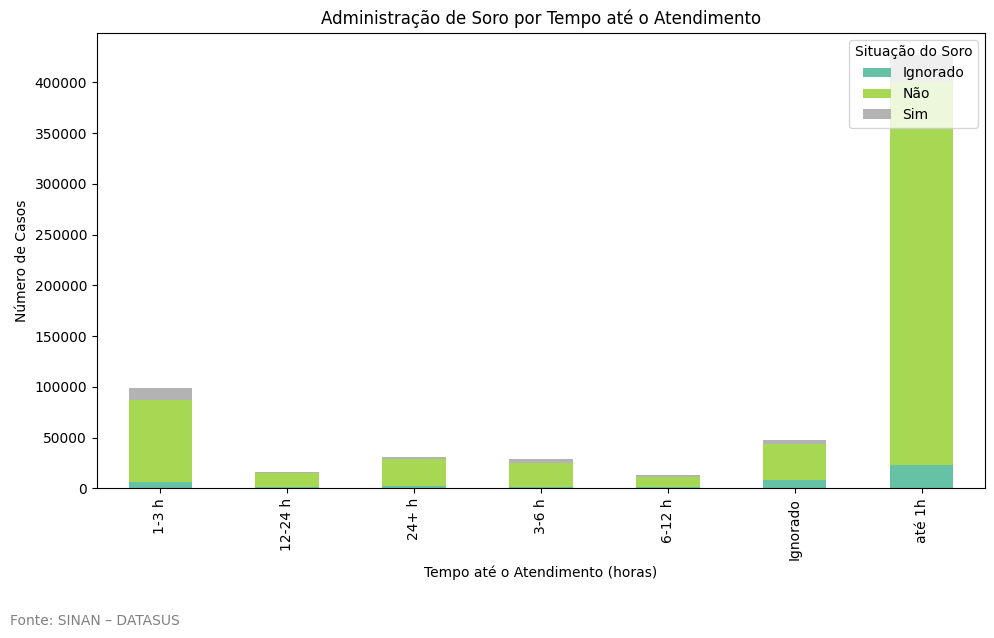

In [ ]:
# Criar o gráfico
ax = soro_tempo.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2',
    title='Administração de Soro por Tempo até o Atendimento'
)

# Eixos
ax.set_xlabel('Tempo até o Atendimento (horas)')
ax.set_ylabel('Número de Casos')

# Legenda
plt.legend(title='Situação do Soro', loc='upper right')

# Fonte abaixo do gráfico
plt.figtext(0.01, -0.05, 'Fonte: SINAN – DATASUS', ha='left', fontsize=10, color='gray')

# Ajustar layout
plt.tight_layout()

# Exibir
plt.show()


In [ ]:
percentual = soro_tempo.div(soro_tempo.sum(axis=1), axis=0) * 100

percentual_plot = percentual.reset_index().melt(id_vars='Tempo', var_name='Recebeu Soro', value_name='Percentual')

fig = px.bar(
    percentual_plot,
    x='Tempo',
    y='Percentual',
    color='Recebeu Soro',
    title='Percentual de Administração de Soro por Tempo até o Atendimento',
    text=percentual_plot['Percentual'].round(1).astype(str) + '%',
    barmode='stack',
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Posicionar o texto dentro das barras
fig.update_traces(textposition='inside')

# Adicionar legenda da fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text='Fonte: SINAN – DATASUS',
            xref='paper', yref='paper',
            x=0, y=-0.2,  # Ajuste conforme necessário
            showarrow=False,
            font=dict(size=12, color='gray'),
            align='left'
        )
    ],
    margin=dict(b=100)  # Aumenta a margem inferior para não cortar o texto
)

fig.show()


## Perfil dos pacientes


### Idade dos pacientes

In [ ]:
df['Idade'].isna().sum()
df['Idade'].unique()

array([4043, 4079, 4004, 4001, 4025, 4003, 4024, 4036, 4007, 4055, 4049,
       4018, 4006, 4034, 4028, 4029, 4065, 4063, 4037, 4011, 4031, 4020,
       4005, 4023, 4033, 4026, 4047, 4013, 4059, 4056, 4022, 4010, 4048,
       4039, 4016, 4019, 4015, 4053, 4041, 4032, 4061, 4017, 4045, 4060,
       4021, 4050, 4068, 4042, 4040, 4012, 4054, 4058, 4052, 4064, 4008,
       4069, 4035, 4030, 4080, 4071, 2000, 2018, 4014, 4027, 4044, 4009,
       4078, 4062, 4046, 4074, 4002, 4051, 4067, 4038, 4057, 3004, 4076,
       4075, 4070, 4072, 4073, 3010, 4077, 4066, 4089, 4084, 4104, 4099,
       3009, 4081, 4082, 2013, 4087, 4085, 3006, 2028, 4086, 4094, 2017,
       3003, 3002, 3008, 3011, 3005, 3001, 4083, 4090, 2001, 2003, 3007,
       2015, 2008, 2023, 4098, 4092, 4097, 4088, 2030, 2027, 2014, 4093,
       2009, 2002, 2005, 4000, 2004, 2006, 4091, 4095, 2020, 2007, 4096,
       2012, 2011, 2024, 2022, 2019, 2016, 2021, 2010, 2038, 4102, 1005,
       3049, 2029, 1007, 3086, 2025, 3013, 4101, 41

In [ ]:
# Converter para string e manter apenas os que têm 4 dígitos
df = df[df['Idade'].astype(str).str.match(r'^\d{4}$')]

In [ ]:
def classificar_faixa(valor):
    try:
        valor = int(valor)
        unidade = int(str(valor)[0])
        numero = int(str(valor)[1:])

        # Converter tudo para idade em anos
        if unidade == 1:
            idade = numero / (24 * 365)
        elif unidade == 2:
            idade = numero / 365
        elif unidade == 3:
            idade = numero / 12
        elif unidade == 4:
            idade = numero
        else:
            return "Ignorado"

        # Classificação em faixas de 10 em 10 anos
        if idade < 10:
            return "0-9 anos"
        elif idade < 20:
            return "10-19 anos"
        elif idade < 30:
            return "20-29 anos"
        elif idade < 40:
            return "30-39 anos"
        elif idade < 50:
            return "40-49 anos"
        elif idade < 60:
            return "50-59 anos"
        elif idade < 70:
            return "60-69 anos"
        elif idade < 80:
            return "70-79 anos"
        elif idade < 90:
            return "80-89 anos"
        elif idade < 100:
            return "90-99 anos"
        else:
            return "100 anos ou mais"
    except:
        return "Ignorado"

In [ ]:
df['faixa_etaria'] = df['Idade'].apply(classificar_faixa)

In [ ]:
casos_idade = pd.crosstab(index=df['faixa_etaria'], columns='Frequência').reset_index()
casos_idade = df['faixa_etaria'].value_counts().reset_index()
casos_idade.columns = ['faixa_etaria', 'Frequência']
casos_idade

,faixa_etaria,Frequência
0,20-29 anos,109067
1,30-39 anos,99504
2,40-49 anos,96612
3,50-59 anos,92613
4,10-19 anos,81183
5,60-69 anos,70414
6,0-9 anos,66572
7,70-79 anos,35081
8,80-89 anos,10355
9,90-99 anos,972


In [ ]:
ordem_idade = [
    '0-9 anos',
    '10-19 anos',
    '20-29 anos',
    '30-39 anos',
    '40-49 anos',
    '50-59 anos',
    '60-69 anos',
    '70-79 anos',
    '80-89 anos',
    '90-99 anos',
    '100 anos ou mais'
]

In [ ]:
casos_idade['faixa_etaria'] = pd.Categorical(
    casos_idade['faixa_etaria'],
    categories=ordem_idade,
    ordered=True
)

casos_idade = casos_idade.sort_values('faixa_etaria')

fig = px.pie(
    casos_idade,
    names='faixa_etaria',
    values='Frequência',
    title="Distribuição de Casos por Faixa Etária",
    color='faixa_etaria',
    category_orders={
        'faixa_etaria': ordem_idade
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(
    sort=False
)

fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80),
    legend_title_text='Faixa etária'
)

fig.show()

In [ ]:
pd.crosstab(df['faixa_etaria'], df['Evolucao'])

Evolucao,1,2,3,9
faixa_etaria,,,,
0-9 anos,61425,95,12,2218
10-19 anos,75466,20,10,2590
100 anos ou mais,45,0,0,1
20-29 anos,101462,15,6,3464
30-39 anos,92290,21,4,3317
40-49 anos,89547,32,9,3232
50-59 anos,86306,49,15,2908
60-69 anos,65802,66,14,2106
70-79 anos,32826,52,8,1021


In [ ]:
# Tabela percentual por faixa etária
tab_evol = pd.crosstab(
    index=df['faixa_etaria'],
    columns=df['Evolucao'],
    normalize='index'
) * 100
tab_evol

Evolucao,1,2,3,9
faixa_etaria,,,,
0-9 anos,96.352941,0.149020,0.018824,3.479216
10-19 anos,96.644725,0.025613,0.012806,3.316856
100 anos ou mais,97.826087,0.000000,0.000000,2.173913
20-29 anos,96.679276,0.014293,0.005717,3.300714
30-39 anos,96.505354,0.021959,0.004183,3.468504
40-49 anos,96.473820,0.034475,0.009696,3.482008
50-59 anos,96.671072,0.054885,0.016801,3.257241
60-69 anos,96.784727,0.097076,0.020592,3.097605
70-79 anos,96.811868,0.153361,0.023594,3.011178


In [ ]:
# Passa para formato longo
tab_evol = tab_evol.reset_index().melt(
    id_vars='faixa_etaria',
    var_name='Evolucao',
    value_name='Percentual'
)
# tab_evol

In [ ]:
# Se tiver dicionário de evolução
tab_evol['Evolução'] = tab_evol['Evolucao'].map(dic_evolucao)

# Ordena faixa etária
tab_evol['faixa_etaria'] = pd.Categorical(
    tab_evol['faixa_etaria'],
    categories=ordem_idade,
    ordered=True
)

tab_evol = tab_evol.sort_values('faixa_etaria')

fig = px.bar(
    tab_evol,
    x='faixa_etaria',
    y='Percentual',
    color='Evolução',
    title='Distribuição dos desfechos por faixa etária',
    labels={
        'faixa_etaria': 'Faixa etária',
        'Percentual': 'Percentual dentro da faixa etária (%)',
        'Evolução': 'Evolução do caso'
    },
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={
        'faixa_etaria': ordem_idade
    },
    text='Percentual'
)

fig.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig.update_layout(
    barmode='group',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=100),
    xaxis_title='Faixa etária',
    yaxis_title='Percentual dentro da faixa etária (%)',
    legend_title_text='Evolução do caso'
)

fig.show()

In [ ]:
# Filtrar apenas os óbitos (EVOLUCAO == 2)
df_obitos = df[df['Evolucao'] == 2]

# Tabela de frequência de óbitos por faixa etária
tab_obt_idade = pd.crosstab(index=df_obitos['faixa_etaria'],
                            columns='Óbitos',
                            dropna=False)

tab_obt_idade.reset_index()

col_0,faixa_etaria,Óbitos
0,0-9 anos,95
1,10-19 anos,20
2,20-29 anos,15
3,30-39 anos,21
4,40-49 anos,32
5,50-59 anos,49
6,60-69 anos,66
7,70-79 anos,52
8,80-89 anos,20
9,90-99 anos,8


In [ ]:
# Garantir que 'faixa_etaria' é uma coluna
if 'faixa_etaria' not in tab_obt_idade.columns:
    tab_obt_idade = tab_obt_idade.reset_index()

# Gráfico de pizza
fig = px.pie(
    tab_obt_idade,
    names='faixa_etaria',
    values='Óbitos',
    title="Distribuição Percentual de Óbitos por Faixa Etária",
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80)
)

fig.show()


In [ ]:
# Garantir que os índices estejam alinhados
tab_obt_idade = tab_obt_idade.copy()
casos_idade = casos_idade.copy()

tab_obt_idade = tab_obt_idade.set_index('faixa_etaria')
casos_idade = casos_idade.set_index('faixa_etaria')

# Calcular o percentual de óbitos por faixa etária
tab_obt_idade['Percentual'] = (
    tab_obt_idade['Óbitos'] * 100 / casos_idade['Frequência']
)

# Formatar o percentual com 3 casas decimais e adicionar símbolo %
tab_obt_idade['Label'] = tab_obt_idade['Percentual'].apply(lambda x: f'{x:.3f}%')

# Resetar o índice para facilitar visualização e uso no gráfico
tab_obt_idade = tab_obt_idade.reset_index()

# Visualizar tabela final
tab_obt_idade

col_0,faixa_etaria,Óbitos,Percentual,Label
0,0-9 anos,95,0.142703,0.143%
1,10-19 anos,20,0.024636,0.025%
2,20-29 anos,15,0.013753,0.014%
3,30-39 anos,21,0.021105,0.021%
4,40-49 anos,32,0.033122,0.033%
5,50-59 anos,49,0.052908,0.053%
6,60-69 anos,66,0.093731,0.094%
7,70-79 anos,52,0.148228,0.148%
8,80-89 anos,20,0.193143,0.193%
9,90-99 anos,8,0.823045,0.823%


In [ ]:
# Garantir ordem da faixa etária
tab_obt_idade['faixa_etaria'] = pd.Categorical(
    tab_obt_idade['faixa_etaria'],
    categories=ordem_idade,
    ordered=True
)

tab_obt_idade = tab_obt_idade.sort_values('faixa_etaria')

# Criar label, caso ainda não exista
# tab_obt_idade['Label'] = (
#     tab_obt_idade['Percentual']
#     .map(lambda x: f'{x:.3f}'.replace('.', ',') + '%')
# )

# Gráfico de barras
fig = px.bar(
    tab_obt_idade,
    x='faixa_etaria',
    y='Percentual',
    text='Label',
    title='Taxa de letalidade por faixa etária',
    labels={
        'faixa_etaria': 'Faixa etária',
        'Percentual': 'Taxa de letalidade (%)'
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Faixa etária',
    yaxis_title='Taxa de letalidade (%)',
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.2,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=100)
)

fig.show()

### Raça/Cor

In [ ]:
tab_raca = pd.crosstab(index=df['Raca'], columns='Frequência').reset_index()
tab_raca

col_0,Raca,Frequência
0,Amarela,4594
1,Branca,419105
2,Ignorado,55516
3,Indígena,1424
4,Parda,145164
5,Preta,36617


In [ ]:
fig = px.pie(
    tab_raca,
    names='Raca',
    values='Frequência',
    title='Distribuição de Casos por Raça/Cor',
    color_discrete_sequence=px.colors.qualitative.Safe
)
# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80)
)
fig.update_traces(textinfo='percent+label', textposition='inside')
fig.show()

In [ ]:
df_obt = df.copy()
df_obt = df_obt[df_obt['Evolucao'] == 2]
df_obt_raca = pd.crosstab(index=df_obt['Raca'], columns='Frequência').reset_index()
df_obt_raca['Percentual'] = df_obt_raca['Frequência'] * 100 / tab_raca['Frequência']
df_obt_raca['Label'] = df_obt_raca['Percentual'].apply(lambda x: f'{x:.3f}%')
df_obt_raca

col_0,Raca,Frequência,Percentual,Label
0,Amarela,8,0.174140,0.174%
1,Branca,242,0.057742,0.058%
2,Ignorado,23,0.041429,0.041%
3,Parda,81,5.688202,5.688%
4,Preta,24,0.016533,0.017%


In [ ]:
# Criar gráfico de barras
fig = px.bar(
    df_obt_raca,
    x='Raca',
    y='Percentual',
    title='Letalidade por Raça/Cor (%)',
    labels={'Percentual': 'Letalidade (%)', 'Raca': 'Raça/Cor'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80)  # Garante espaço inferior para exibir a fonte
)

fig.show()

### Gênero

In [ ]:
genero_abs = pd.crosstab(index=df['Sexo'], columns='Frequência').reset_index()
genero_abs

col_0,Sexo,Frequência
0,Feminino,281378
1,Ignorado,242
2,Masculino,380800


In [ ]:
# Gráfico de pizza
fig = px.pie(
    genero_abs,
    names='Sexo',
    values='Frequência',
    title="Distribuição de Casos por Gênero",
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80)  # Garante espaço inferior para exibir a fonte
)

fig.show()

### Grávidas

In [ ]:
pd.crosstab(index=df['Gestante'], columns='Frequência').reset_index()

col_0,Gestante,Frequência
0,1o Trimestre,1486
1,2o Trimestre,1838
2,3o Trimestre,1151
3,Idade gestacional ignorada,338
4,Ignorado,31597
5,Não,178871
6,Não se aplica,447139


In [ ]:
df['Gesta_status'] = df['Gestante'].apply(
    lambda x: 'Não' if x in ['Não', 'Não se aplica', 'Ignorado'] else 'Sim'
)

In [ ]:
tabela_ges = pd.crosstab(index=df['Gesta_status'], columns='Frequência').reset_index()
tabela_ges


col_0,Gesta_status,Frequência
0,Não,657607
1,Sim,4813


In [ ]:
df_gest = df.copy()
df_gest = df_gest[df_gest['Gesta_status'] == 'Sim']
pd.crosstab(index=df_gest['Evolucao'], columns='Frequência').reset_index()

col_0,Evolucao,Frequência
0,1,4464
1,9,157


Não há registro de morte por animais peçonhentos em gestantes

### Escolaridade

In [ ]:
escol = pd.crosstab(index=df['Escolaridade'], columns='Frequência').reset_index()
escol

col_0,Escolaridade,Frequência
0,1a a 4a série incompleta do EF,54468
1,4a série completa do EF,32117
2,5a a 8a série completa do EF,67674
3,Ensino fundamental completo,40534
4,Ensino médio completo,124778
5,Ensino médio incompleto,49632
6,Ensino superior completo,21202
7,Ensino superior incompleto,8903
8,Ignorado,217175
9,Não se aplica,45937


In [ ]:
ordem_escolaridade = [
    '1a a 4a série incompleta do EF',
    '4a série completa do EF',
    '5a a 8a série completa do EF',
    'Ensino fundamental completo',
    'Ensino médio incompleto',
    'Ensino médio completo',
    'Ensino superior incompleto',
    'Ensino superior completo',
    'Não se aplica',
    'Ignorado'
]


fig = px.pie(
    escol,
    names='Escolaridade',
    values='Frequência',
    title='Distribuição de Casos por Escolaridade',
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={'Escolaridade': ordem_escolaridade}
)

# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.1,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="left"
        )
    ],
    margin=dict(b=80)  # Garante espaço inferior para exibir a fonte
)

fig.update_traces(textinfo='percent+label', textposition='inside')
fig.show()



In [ ]:
df_escol = df.copy()
df_escol = df_escol[df_escol['Evolucao'] == 2]
escol_obt = pd.crosstab(index=df_escol['Escolaridade'], columns='Frequência').reset_index()
escol_obt['Percentual'] = escol_obt['Frequência'] * 100 / escol['Frequência']
escol_obt['Label'] = escol_obt['Percentual'].apply(lambda x: f'{x:.3f}%')
escol_obt

col_0,Escolaridade,Frequência,Percentual,Label
0,1a a 4a série incompleta do EF,44,0.080781,0.081%
1,4a série completa do EF,22,0.068500,0.068%
2,5a a 8a série completa do EF,41,0.060585,0.061%
3,Ensino fundamental completo,15,0.037006,0.037%
4,Ensino médio completo,26,0.020837,0.021%
5,Ensino médio incompleto,8,0.016119,0.016%
6,Ensino superior completo,11,0.051882,0.052%
7,Ensino superior incompleto,4,0.044929,0.045%
8,Ignorado,135,0.062162,0.062%
9,Não se aplica,72,0.156736,0.157%


In [ ]:
fig = px.bar(
    escol_obt,
    x='Escolaridade',
    y='Percentual',
    title='Letalidade por Escolaridade (%)',
    labels={'Percentual': 'Percentual de letalidade', 'Escolaridade': 'Nível de Escolaridade'},
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Adicionar fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0, y=-0.4,  # menos negativo = mais próximo do gráfico
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="center"
        )
    ],
    margin=dict(b=120)  # margem inferior aumentada
)

fig.show()


### Acidente de trabalho

In [ ]:
# Agrupando os dados por "Relacionado ao Trabalho" e contando os casos
filtered_data = df.groupby(["Doenca_Trabalho"]).size().reset_index(name="Casos")

fig = px.bar(
    filtered_data,
    x="Doenca_Trabalho",
    y="Casos",
    title="Casos relacionados ao trabalho",
    labels={"Casos": "Número de Casos", "Doenca_Trabalho": "Relacionado ao Trabalho"},
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Adicionar a fonte abaixo do gráfico
fig.update_layout(
    annotations=[
        dict(
            text="Fonte: SINAN – DATASUS",
            xref="paper", yref="paper",
            x=0.5, y=-0.3,
            showarrow=False,
            font=dict(size=12, color="gray"),
            align="center"
        )
    ],
    margin=dict(b=120)  # espaço inferior maior para acomodar a fonte
)

fig.show()